In [ ]:
import marimo as mo

# IIA - Trabajo Práctico 3 - Redes Neuronales

In [ ]:
import os
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
from joblib import Parallel, delayed


import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

from copy import deepcopy

# Explorando las Redes

In [ ]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas = 25   # numero de epocas que entrena cada vez
super_epocas = 100 # numero de veces que realizaremos sub-epocas
# épocas ~= sub_epocas * super_epocas
eta = 0.01        # learning rate
alfa = 0.9        # momentum
N2 = 60            # neuronas en la capa oculta

## Definimos nuestras redes

In [ ]:
# Defino MLP para regresión
regr = MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(regr)

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [ ]:
# Defino MLP para clasificación
clasif = MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(clasif)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Entrenamos

> **Warning**: el entrenamiento de las redes es computacionalmente pesado. Algunos de los entrenamientos que se plantean en el trabajo llevan varios minutos, dependiendo de la velocidad del procesador. El tiempo máximo en Google Colab fue de alrededor de 10 minutos. Tengan eso en cuenta para hacer el trabajo.

In [ ]:
def cargar_csv(path, xcols=2, separator=','):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    df = pd.read_csv(path, header=None, sep=separator)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

In [ ]:
def entrenar_red(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red

    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

In [ ]:
# Cargamos los datos...
X, y = cargar_csv('./data/xor.csv')
X2, X_test, y2, y_test = skl.model_selection.train_test_split(X, y, test_size=0.2)
# Hacemos el split de training y testing
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X2, y2, test_size=0.2)
# y spliteamos el training en training y validacion
# Corremos el entrenamiento
clasif_1, e_train, e_val, e_test = entrenar_red(clasif, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)  # para xor de 200 me quedan 40 de test  # para xor de 160 me quedan 32 de val

/home/julian-paz/Facultad/04_Cuarto_Año/R413_Introduccion_a_la_Inteligencia_Artificial/TP-RN/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/julian-paz/Facultad/04_Cuarto_Año/R413_Introduccion_a_la_Inteligencia_Artificial/TP-RN/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/julian-paz/Facultad/04_Cuarto_Año/R413_Introduccion_a_la_Inteligencia_Artificial/TP-RN/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/julian-paz/Facultad/04_Cuarto_Año/R413_Introdu

## Ploteamos Algunas Métricas

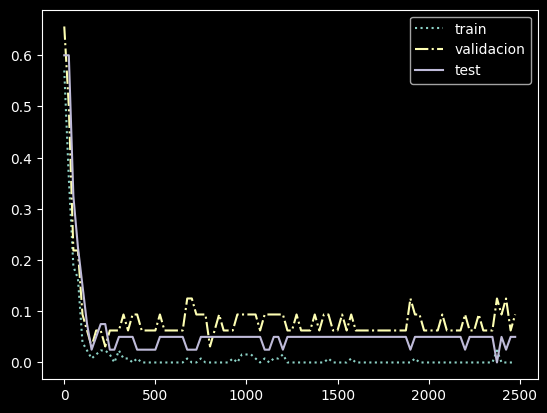

In [ ]:
rango = np.array(range(super_epocas)) * sub_epocas
plt.plot(rango, e_train, label="train", linestyle=":")
plt.plot(rango, e_val, label="validacion", linestyle="-.")
plt.plot(rango, e_test, label="test", linestyle="-")
plt.legend()
plt.show()

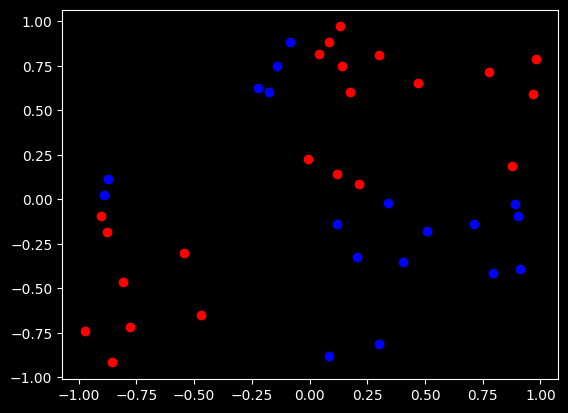

In [ ]:
y_out = clasif_1.predict(X_test)
X_out = X_test.copy()
X_out[2] = y_out
_c0 = X_out.loc[X_out[2] == 0]
_c1 = X_out.loc[X_out[2] == 1]
_xs0 = _c0[0].values.tolist()
_ys0 = _c0[1].values.tolist()
_xs1 = _c1[0].values.tolist()
_ys1 = _c1[1].values.tolist()
plt.scatter(_xs0, _ys0, color='red')
plt.scatter(_xs1, _ys1, color='blue')
plt.show()

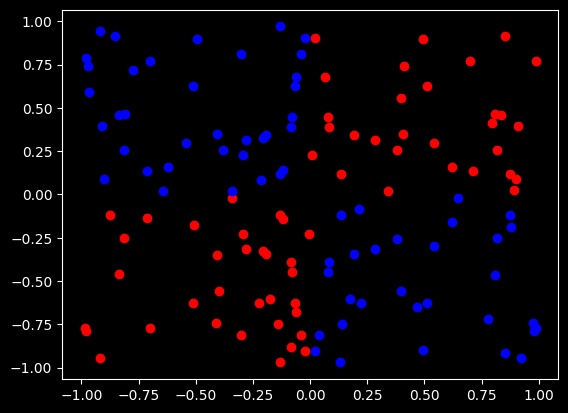

In [ ]:
# diferenciar entre clase 0 y clase 1
Xt = X_train.copy()
Xt[2] = y_train
_c0 = Xt.loc[Xt[2] == 0]
_c1 = Xt.loc[Xt[2] == 1]
_xs0 = _c0[0].values.tolist()
_ys0 = _c0[1].values.tolist()
_xs1 = _c1[0].values.tolist()
_ys1 = _c1[1].values.tolist()
plt.scatter(_xs0, _ys0, color='red')
plt.scatter(_xs1, _ys1, color='blue')
plt.show()

# Algunas funciones que fuimos usando

## Funciones de entrenamiento

In [ ]:
def entrenar_red_wd_clasf(
    red,
    evaluaciones,
    gamma,
    X_train,
    y_train,
    X_test,
    y_test,
    ord=2,
):
    """
    Función que entrena una red para clasificación ya definida
    previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, test y la suma de los pesos cada uno al cuadrado
    (o su valor absoluto, dependiendo del argumento ord) al terminar ese paso
    de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error total
    (ErrorTrain + SumaCuadradaPesos).

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      gamma: El valor del hiperparámetro gamma con el que fue configurada la red
      X_{}: los conjuntos de valores de entrada de train y test
      y_{}: los conjuntos de valores de salida
      ord: La norma que se va a utilizar

    Salidas:
      best_red: la red entrenada en el mínimo error total
      error_{}: los errores de: train, test medidos en cada evaluación
      weights: La suma de los pesos al cuadrado (o su valor absoluto,
      dependiendo del argumento ord).
    """

    # Nos fijamos que no usen una norma extraña (que no sea 1 o 2)
    if (ord != 1) and (ord != 2):
        print("ord Incorrecto, utilice ord=1 o ord=2")
        return red, [], [], []

    # Inicializamos las listas que vamos a retornar
    error_train = []
    error_test = []
    norm_weights = []

    # Inicializamos las variables que nos permiten quedarnos/decidir cual es la mejor red
    min_error = np.inf
    best_red = red

    for epoch in range(evaluaciones):
        # Entrenamos la red
        red.fit(X_train, y_train)

        # Error de training
        y_pred_train = red.predict(X_train)
        e_train = zero_one_loss(y_train, y_pred_train)
        error_train.append(e_train)

        # Obtenemos los pesos de la red
        weights = red.coefs_

        # Obtenemos la norma 'ord' de los pesos en la evaluación
        # weights[0] -> Pesos que van desde la capa de entrada a la capa oculta
        # weights[1] -> Pesos que van desde la capa oculta a la capa de salida
        cur_norm_weights = np.linalg.norm(np.concatenate((weights[0].flatten(),
                                                          weights[1].flatten())
                                                        ), ord)

        # Si tenemos la norma 2, elevamos el vector de pesos al cuadrado
        if ord == 2:
            cur_norm_weights = cur_norm_weights * cur_norm_weights
        norm_weights.append(cur_norm_weights)

        # Error de test
        error_test.append(1 - red.score(X_test, y_test))

        # Error total (con el cual determinamos que red es mejor)
        total_error = e_train + gamma * cur_norm_weights

        # Nos quedamos con la mejor red
        if min_error > total_error:
            min_error = total_error
            best_red = deepcopy(red)
    return best_red, error_train, error_test, norm_weights

In [ ]:
def entrenar_red_wd(
    red,
    evaluaciones,
    gamma,
    X_train,
    y_train,
    X_test,
    y_test,
    ord=1,
):
    """
    Función que entrena una red para regresión ya definida
    previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, test y la suma de los pesos cada uno al cuadrado
    (o su valor absoluto, dependiendo del argumento ord) al terminar ese paso
    de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error total
    (ErrorTrain + SumaCuadradaPesos).

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      gamma: El valor del hiperparámetro gamma con el que fue configurada la red
      X_{}: los conjuntos de valores de entrada de train y test
      y_{}: los conjuntos de valores de salida
      ord: La norma que se va a utilizar

    Salidas:
      best_red: la red entrenada en el mínimo error total
      error_{}: los errores de: train, test medidos en cada evaluación
      weights: La suma de los pesos al cuadrado (o su valor absoluto,
      dependiendo del argumento ord).
    """

    # Nos fijamos que no usen una norma extraña (que no sea 1 o 2)
    if (ord != 1) and (ord != 2):
        print("ord Incorrecto, utilice ord=1 o ord=2")
        return red, [], [], []

    # Inicializamos las listas que vamos a retornar
    error_train = []
    error_test = []
    norm_weights = []

    # Inicializamos las variables que nos permiten quedarnos/decidir cual es la mejor red
    min_error = np.inf
    best_red = red

    for epoch in range(evaluaciones):
        # Entrenamos la red
        red.fit(X_train, y_train)

        # Error de training
        y_pred_train = red.predict(X_train)
        e_train = mean_squared_error(y_train, y_pred_train)
        error_train.append(e_train)

        # Obtenemos los pesos de la red
        weights = red.coefs_

        # Obtenemos la norma 'ord' de los pesos en la evaluación
        # weights[0] -> Pesos que van desde la capa de entrada a la capa oculta
        # weights[1] -> Pesos que van desde la capa oculta a la capa de salida
        cur_norm_weights = np.linalg.norm(np.concatenate((weights[0].flatten(),
                                                          weights[1].flatten())
                                                        ), ord)

        # Si tenemos la norma 2, elevamos el vector de pesos al cuadrado
        if ord == 2:
            cur_norm_weights = cur_norm_weights * cur_norm_weights
        norm_weights.append(cur_norm_weights)

        # Error de test
        y_predict_test = red.predict(X_test)
        error_test.append(mean_squared_error(y_predict_test, y_test))

        # Error total (con el cual determinamos que red es mejor)
        total_error = e_train + gamma * cur_norm_weights

        # Nos quedamos con la mejor red
        if min_error > total_error:
            min_error = total_error
            best_red = deepcopy(red)
    return best_red, error_train, error_test, norm_weights

In [ ]:
def entrenar_red_rgr(red, evaluaciones,
                     X_train, y_train,
                     X_val,   y_val,
                     X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """

    # Inicializamos las listas que vamos a devolver
    error_train = []
    error_val = []
    error_test = []

    # Inicializamos las variables que nos permiten quedarnos/decidir cual es la mejor red
    best_val = np.inf
    best_red = red

    for epoch in range(evaluaciones):
      # Entrenamos la red
      red.fit(X_train, y_train)

      # Error de training
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))

      # Error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = mean_squared_error(y_val, y_pred_val)
      error_val.append(cur_val)

      # Error de test
      y_pred_test = red.predict(X_test)
      error_test.append(mean_squared_error(y_pred_test, y_test))

      # Nos quedamos con la mejor red
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)

    return best_red, error_train, error_val, error_test

## Funciones de ploteo

In [ ]:
def plot_errors(graph, training_error, testing_error, val_error, super_epocas, sub_epocas):

    """
    plot_errors plotea un conjunto de errores de entrenamiento, validación y
    testeo de una red neuronal, en base a las épocas.

    Argumentos:
      graph: Gráfico sobre el que se van a plotear los errores
      training_error: El conjunto de errores de entrenamiento en cada super época
      testing_error: El conjunto de errores de test en cada super época
      val_error: El conjunto de errores de validación en cada super época
      super_epocas: La cantidad de super épocas
      sub_epocas: La cantidad de épocas

    Salidas:
      graph: El gráfico con los errores ploteados
    """

    # Creamos el eje x.
    rango = np.array(range(super_epocas)) * sub_epocas

    # Ploteamos los errores
    graph.plot(rango, training_error, label="train", linestyle=":")
    graph.plot(rango, testing_error, label="test", linestyle="-")
    graph.plot(rango, val_error, label="validation", linestyle="-.")

    # Colocamos los labels a los ejes
    graph.set_xlabel('Epocas')
    graph.set_ylabel('Errores')


    # Activamos que el fondo sea grillado y la leyenda de los líneas
    graph.grid(True)
    graph.legend()

    return graph

In [ ]:
def plot_error_wd(graph, training_error, testing_error, gammas):
    """
    plot_error_wd plotea un conjunto de errores de entrenamiento y
    testeo promedio de una red neuronal, en base al valor del hiperparámetro
    gamma utilizado para configurar la red neuronal.

    Argumentos:
      graph: Gráfico sobre el que se van a plotear los errores
      training_error: El conjunto de errores de entrenamiento promedio para cada valor de gamma
      testing_error: El conjunto de errores de test promedio para cada valor de gamma
      gammas: El conjunto de valores que toma el hiperparámetro gamma

    Salidas:
      graph: El gráfico con los errores ploteados
    """

    # Ploteamos los errores de entrenamiento y testeo
    graph.plot(gammas, training_error, label="train",
                  linestyle=":", marker="o", color="blue", linewidth=2)

    graph.plot(gammas, testing_error, label="test", linestyle="-",
                  marker="o", color="red", linewidth=2)

    # Colocamos los labels a los ejes
    graph.set_xlabel('Valor gamma (en escala logarítmica)')
    graph.set_ylabel('Errores')

    # 
    graph.set_xscale('log')

    # Activamos que el fondo sea grillado y la leyenda de los líneas
    graph.grid(True)
    graph.legend()

    # Devolvemos el gráfico modificado
    return graph

In [ ]:
def plot_errors_wd(graph, training_error, testing_error, super_epocas, sub_epocas):

    """
    plot_errors_wd plotea un conjunto de errores de entrenamiento y
    testeo de una red neuronal, en base a las épocas.

    Argumentos:
      graph: Gráfico sobre el que se van a plotear los errores
      training_error: El conjunto de errores de entrenamiento en cada super época
      testing_error: El conjunto de errores de test en cada super época
      super_epocas: La cantidad de super épocas
      sub_epocas: La cantidad de épocas

    Salidas:
      graph: El gráfico con los errores ploteados
    """

    # Creamos el eje x.
    rango = np.array(range(super_epocas)) * sub_epocas

    # Ploteamos los errores
    graph.plot(rango, training_error, label="train", linestyle=":")
    graph.plot(rango, testing_error, label="test", linestyle="-")

    # Colocamos los labels a los ejes
    graph.set_xlabel('Epocas')
    graph.set_ylabel('Errores')

    # Activamos que el fondo sea grillado y la leyenda de los líneas
    graph.grid(True)
    graph.legend()

    return graph

In [ ]:
def plot_penalization(graph, penalizations, super_epocas, sub_epocas):

    """
    plot_penalization plotea un conjunto de penalizaciones de una red neuronal, en base a las épocas.

    Argumentos:
      graph: Gráfico sobre el que se van a plotear los errores
      penalizations: El conjunto de penalizaciones en base a las épocas
      super_epocas: La cantidad de super épocas
      sub_epocas: La cantidad de épocas

    Salidas:
      graph: El gráfico con las penalizaciones ploteados
    """

    # Creamos el eje x.
    rango = np.array(range(super_epocas)) * sub_epocas

    # Ploteamos los errores
    graph.plot(rango, penalizations, linestyle="-")

    # Colocamos los labels a los ejes
    graph.set_xlabel('Épocas')
    graph.set_ylabel('Penalización')

    # Activamos que el fondo sea grillado
    graph.grid(True)

    return graph

In [ ]:
def plot_error_dimensions(graph, dimensions, e_train_graph, e_test_graph, total_errors_graph):

    graph.plot(dimensions, e_train_graph, marker='o', linestyle='-', color='tab:blue', label='Error Train')
    graph.plot(dimensions, e_test_graph, marker='o', linestyle='-', color='tab:orange', label='Error Test')
    graph.plot(dimensions, total_errors_graph, marker='o', linestyle='-', color='tab:red', label='Error Total (Penalizado)')

    graph.set_xlabel('Dimensiones (d)')
    graph.set_ylabel('Error')
    graph.set_title('Evolución de los errores según la dimensionalidad')

    graph.set_xticks(dimensions) 

    graph.grid(True, linestyle='--', alpha=0.6)
    graph.legend()

    return graph

In [ ]:
def plot_classification(results, size_ds, feature_names, target_names):
    X_test, y_test = results["X_test"], results["y_test"]

    _, ax = plt.subplots(size_ds, 2, sharey=True, figsize=(20, 20), squeeze=False)

    for i in range(size_ds):
        # Ploteamos los datos reales a la izquierda
        scatter_true = ax[i, 0].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap="bwr")
        ax[i, 0].set(xlabel=feature_names[0], ylabel=feature_names[1])
        _ = ax[i, 0].legend(
            scatter_true.legend_elements()[0], target_names, loc="lower right", title="Classes (True)"
        )

        # Ploteamos los datos predecidos a la derecha
        scatter_pred = ax[i, 1].scatter(X_test[:,0], X_test[:,1],
                                        c=results["nns"][i]["y_predict"], s=10, cmap="bwr")
        ax[i, 1].set(xlabel=feature_names[0], ylabel=feature_names[1])
        _ = ax[i, 1].legend(
            scatter_pred.legend_elements()[0], target_names, loc="lower right", title="Classes (Pred)"
        )


    plt.show()

# Ejercicio 1. Capacidad de Modelado.

## Entrenamos la red

In [ ]:
# Incluimos la generación de espirales
import spiral as spiral

In [ ]:
def res_ej1():
    # Generamos los datos
    data = spiral.espirales(2600)
    X, y = np.vstack(data.input.values), data.output

    # Hacemos el split de training y testing (~600)
    X2, X_test, y2, y_test = skl.model_selection.train_test_split(X, y, test_size=0.23)

    # Spliteamos el training en training y validación
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X2, y2, test_size=0.20)

    # Parámetros 1
    sub_epocas = 20          # número de épocas que entrena cada vez
    eval = 1000              # número de veces que realizaremos sub-epocas
    # épocas ~= sub_epocas * super_epocas
    eta = 0.1                # learning rate
    alfa = 0.9               # momentum
    N2 = [2, 10, 20, 40]     # neuronas en la capa oculta

    res = []


    for i in range(len(N2)):

        clasif = MLPClassifier(
            hidden_layer_sizes=(N2[i],), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=eta,
            momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=sub_epocas,
        )

         # Corremos el entrenamiento
        clasif, e_train, e_val, e_test = entrenar_red(clasif, eval, X_train, y_train, X_val, y_val, X_test, y_test)  

        res.append( {"clasif"    : clasif,
                     "y_predict" : clasif.predict(X_test),
                     "e_train"   : e_train,
                     "e_val"     : e_val,
                     "e_test"    : e_test} )


    # Devolvemos un diccionario donde neurons y nns son una lista
    # de len(N2) dimensiones donde neurons[i] es la cantidad de
    # neuronas utilizadas en la capa escondida de la red neuronal nns[i]
    return { "X_test"  : X_test,
             "y_test"  : y_test,
             "nns"     : res 
           }

## Ploteamos los errores

In [ ]:
_archivo_cache = "resultados_ej1.pkl"

if os.path.exists(_archivo_cache):
    ej1 = joblib.load(_archivo_cache)
else:
    ej1 = res_ej1()
    joblib.dump(ej1, _archivo_cache)

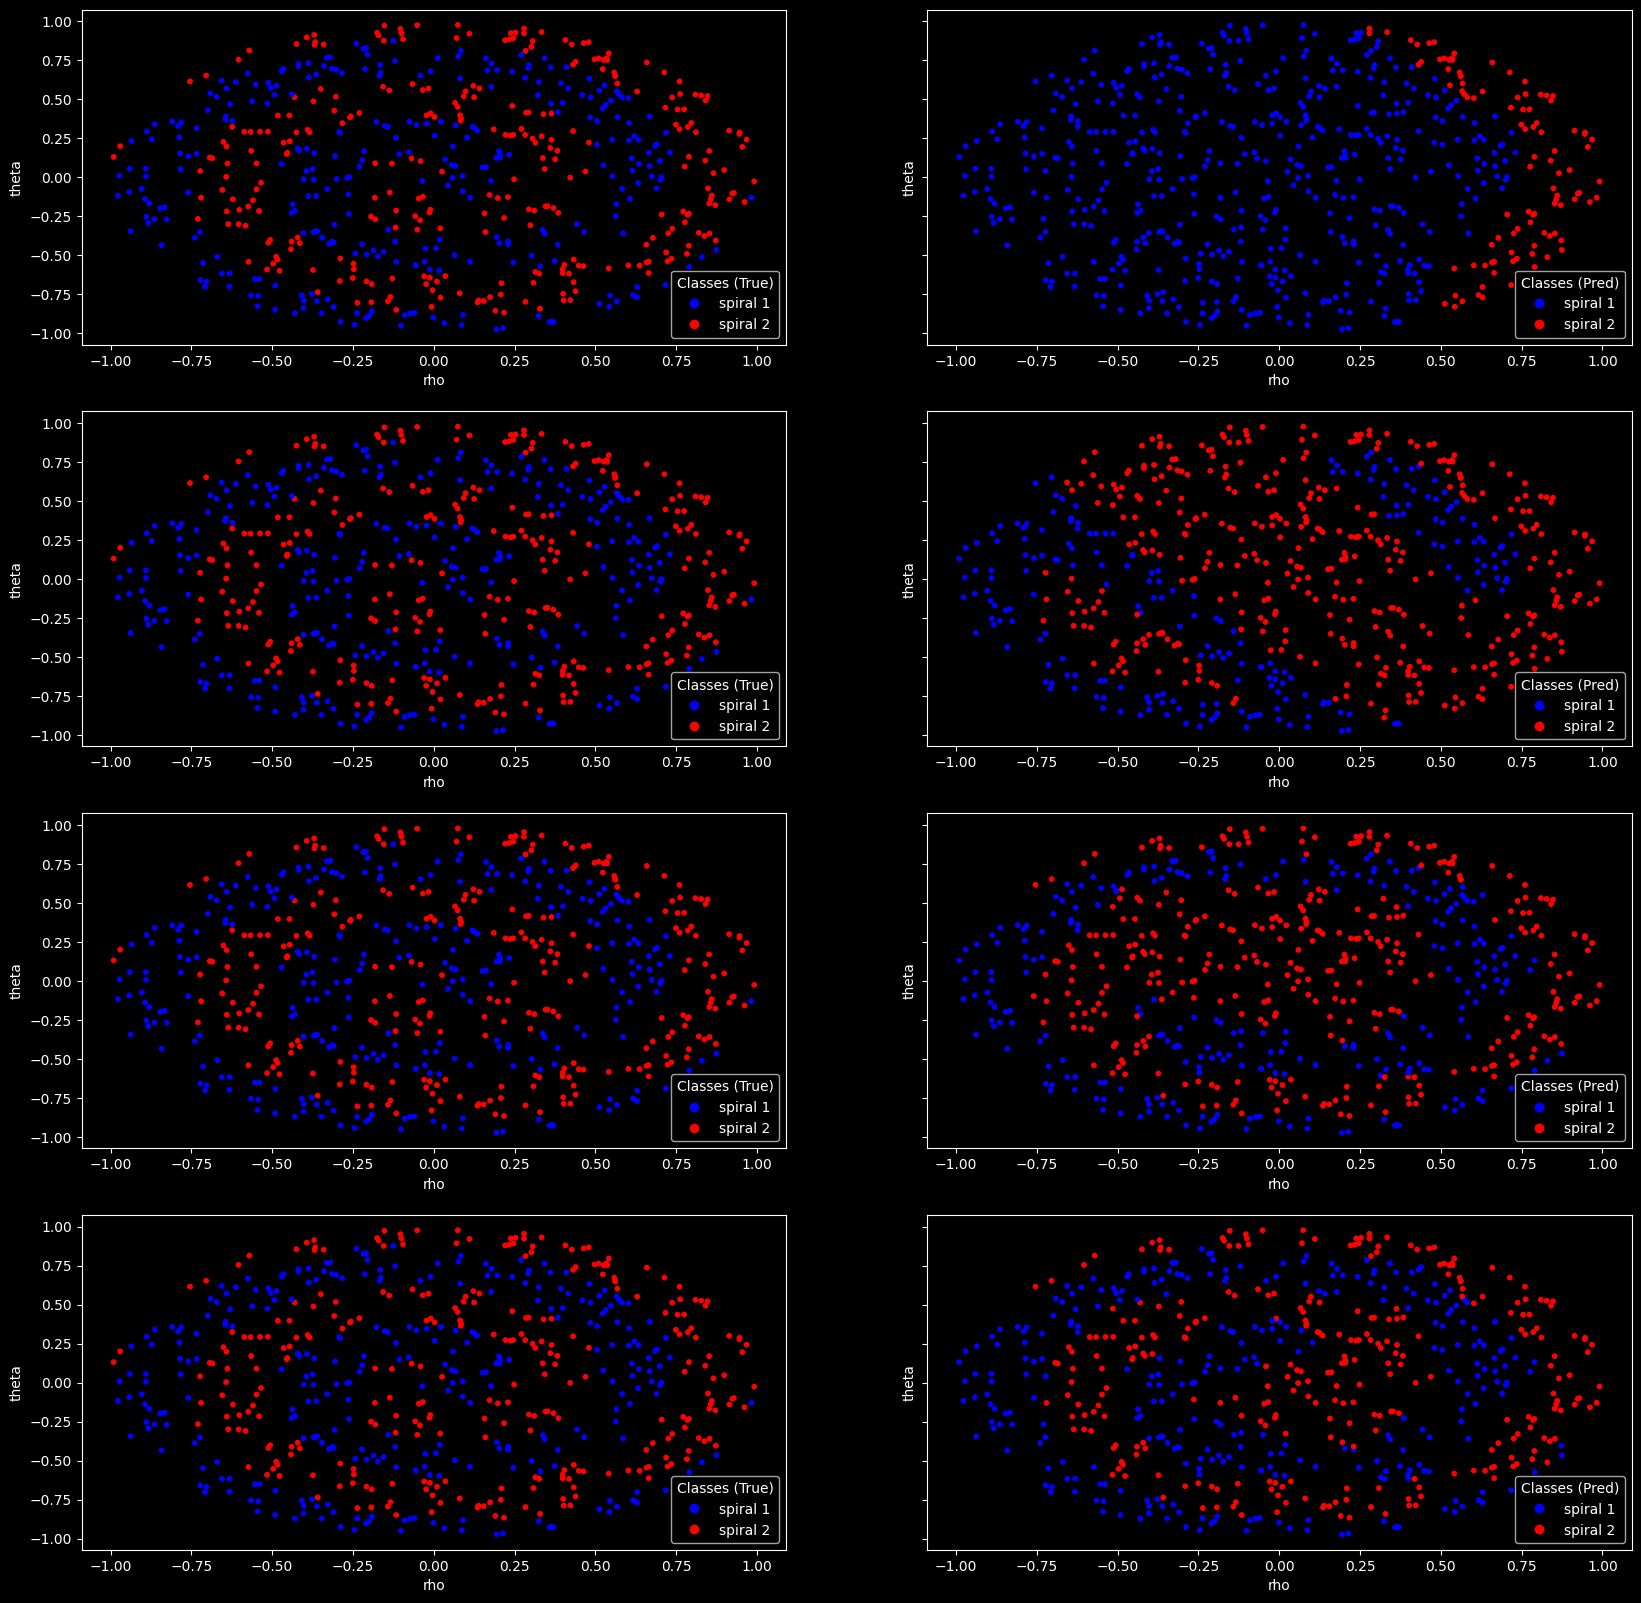

In [ ]:
# Ploteamos 
size = len(ej1["nns"])
plot_classification( ej1,
                     size,
                    ["rho", "theta"],
                    ["spiral 1", "spiral 2"])

## Conclusión

En las gráficas podemos ver que mientras incrementamos el número de
neuronas en la hidden layer obtenemos una mejor clasificación. Esto se
debe, a que cuando combinamos sigmoids (las de la capa intermedia en el
perceptron final) podemos aproximar de mejor manera, es decir,
obtenemos una mejor clasificación.

Sin embargo, agregar neuronas en la capa intermedia puede provocar
overfitting, ya que la red neuronal aprende ruido de los datos de
entrenamiento. Pareciera no ser el caso de este ejercicio.

Comparando con la clasificación hecha con árboles de decisión vemos que,
a pesar del tiempo de entrenamiento de las redes neuronales (que es
mayor) se obtiene una peor clasificación.

Vemos entonces, que las redes neuronales no son la solución óptima para
todos los problemas. En este ejercicio, podemos ver como los árboles
clasifican los datos de mejor manera y en un menor tiempo que ellas.

# Ejercicio 2. Mínimos Locales.

Para este ejercicio es importante entender que:

**Learning rate**
El learning rate es un valor que indica que tanta importancia le damos, al momento de ajustar
los pesos, a los errores de aproximación (que tanto aprendemos de los errores).

Un learning rate bajo hace que los pesos se ajusten de a poco. Esto puede provocar que el valor de los pesos se quede estancado en un mínimo local (ya que la derivada
parcial es igual a 0). En contraposición, un learning rate alto ajusta los pesos de manera
más agresiva, esto puede provocar que los valores de los pesos se escapen o sobrepasen
mínimos locales, pero puede que además sobrepasen al mínimo global.

**Momentum**
El momentum agrega un término en la corrección de los pesos de cada
iteración del algoritmo (suma momentum * variacion_peso). Representa la inercia
de la variación de los pesos. Esto logra que aún cayendo en un mínimo local (punto
donde la la derivada parcial del error se hace 0) nos podamos salir del mismo
(ya que este término no se anula por más que la derivada sea 0).

Ahora bien, valores muy altos pueden generar que nos escapemos incluso del mínimo global. Por otro lado, un valor muy pequeño puede hacer que no sobrepasemos los mínimos locales. Un valor adecuado nos ayudara a sobrepasar mínimos locales y no escaparnos del mínimo global.

## Entrenamos la red

In [ ]:
def cargar_datos_ej2():
    # Cargamos los datos
    X, y = cargar_csv('./data/dos_elipses.data')
    X_test, y_test = cargar_csv('./data/dos_elipses.test')
    # Hacemos el split de training y testing
    X2, _, y2, _ = skl.model_selection.train_test_split(X, y, test_size=0.5)

    # spliteamos el training en training y validacion
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X2, y2, test_size=0.2)
    return X_test, X_train, X_val, y_test, y_train, y_val

In [ ]:
def res_ej2(eta, alfa):
    iter = 10

    # Parámetros 1
    # eta := learning rate | alfa := momentum
    sub_epocas = 50          # número de épocas que entrena cada vez
    eval = 300              # número de veces que realizaremos sub-epocas
    # epocas ~= sub_epocas * super_epocas
    N2 = 6     # neuronas en la capa oculta

    nns = []

    for i in range(iter):
        # Generamos los datos
        X_test, X_train, X_val, y_test, y_train, y_val = cargar_datos_ej2()

        clasif = MLPClassifier(
            hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=eta,
            momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=sub_epocas
        )

         # Corremos el entrenamiento
        clasif, e_train, e_val, e_test = entrenar_red(clasif, eval, X_train, y_train, X_val, y_val, X_test, y_test)  

        nns.append( {"clasif"    : clasif,
                     "e_train"   : e_train,
                     "e_val"     : e_val,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "learning_rate" : eta,
             "momentum" : alfa,
             "super_epocas" : eval,
             "sub_epocas" : sub_epocas
           }

Primero entrenamos la red con distintas combinaciones de hiper-parámetros. Entre ellos no solo encontramos las combinaciones recomendadas, también agregamos un amplio conjunto de combinaciones que nos parecieron útiles para obtener una conclusión.

In [ ]:
_archivo_cache = "resultados_ej2.pkl"

if os.path.exists(_archivo_cache):
    ej2 = joblib.load(_archivo_cache)

else:
    ej2 = {
             "nns" : [],
             "learning_rate": [],
             "momentum": [],
             "super_epocas" : [],
             "sub_epocas" : []
          }

    ej2_cases = [
        (0.1, 0), (0.01, 0), (0.001, 0), (0.1, 0.5), (0.1, 0.9),
        (0.20, 0.9), (0.20, 0.5), (0.30, 0.9), (0.30, 0.5),
        (0.01, 0.5), (0.01, 0.9), (0.001, 0.5), (0.001, 0.9),
        (0.15, 0.5), (0.25, 0.5), (0.25, 0.75), (0.25, 0.25),
        (0.275, 0.25), (0.225, 0.25), (0.25, 0.20), (0.25, 0.30)
    ]

    # 1. Ejecutamos todos los casos en paralelo
    _res_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej2)(_eta, _alfa) for _eta, _alfa in ej2_cases
    )

    for _res in _res_paralelos:
        ej2["nns"].append(_res["nns"])
        ej2["learning_rate"].append(_res["learning_rate"])
        ej2["momentum"].append(_res["momentum"])
        ej2["super_epocas"].append(_res["super_epocas"])
        ej2["sub_epocas"].append(_res["sub_epocas"])

    joblib.dump(ej2, _archivo_cache)

## Ploteamos la tabla

Luego de haber entrenado las redes, plasmamos en una tabla los resultados de los distintos entrenamientos. En la tabla se pueden observar el error promedio que tiene una red con cierta combinación de hiper-parámetros.

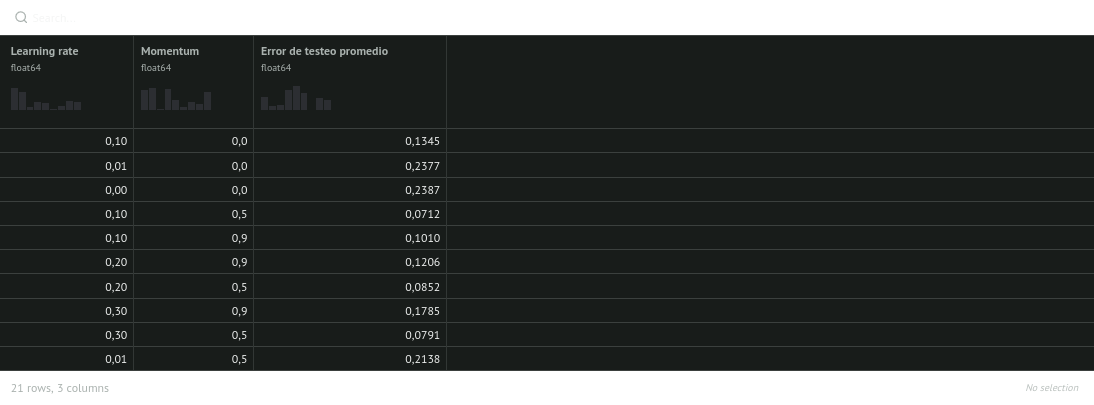

In [ ]:
# Creamos y mostramos la tabla
_aux_table_ej2 = {
                   "Learning rate": [],
                   "Momentum": [],
                   "Error de testeo promedio": [],
                 }

for _i in range(len(ej2["nns"])):
    _errs_test = []
    for _j in range(len(ej2["nns"][_i])):
        _min_e_val = min(ej2["nns"][_i][_j]["e_val"])
        _k = ej2["nns"][_i][_j]["e_val"].index(_min_e_val)
        _errs_test.append(ej2["nns"][_i][_j]["e_test"][_k])

    _aux_table_ej2["Error de testeo promedio"].append(round(np.mean(_errs_test),4))
    _aux_table_ej2["Momentum"].append(round(ej2["momentum"][_i],2))
    _aux_table_ej2["Learning rate"].append(round(ej2["learning_rate"][_i],2))

table_ej2 = pd.DataFrame(_aux_table_ej2)
table_ej2

### Con cual combinación nos quedamos:

En dicha tabla podemos observar que la mejor combinación de hiper-parámetros es la que tiene:

- learning rate = 0.25

- momentum = 0.5

ya que posee el menor error promedio de testeo (aproximadamente 6%).

Ahora bien, como nos piden graficar los errores en función de las épocas para estos valores de eta y alfa, resulta que debemos elegir alguna de las redes que entrenamos con dicha combinación de hiper-parámetros (una de las 10 redes entrenadas). Por lo tanto, elegimos la red que posee el menor error de validación.

Antes de plotear el error, nos parece importante resaltar porqué tomamos estas decisiones.

Para determinar con exactitud el rendimiento de un combinación de hiper-parámetros sobre un problema (qué tan bien generaliza mi red con esa combinación de hiper-parámetros), deberíamos calcular el error real que tiene la red al ser evaluada en todos los casos posibles del problema. Si hicieramos esto para cada combinación de hiper-parámetros, podríamos determinar con certeza cuál de todas estas combinaciones es la que permite generalizar mejor (aquella que posea el menor error).

El problema es que, en el mundo real rara vez esto es posible. Ya que no tenemos este conjunto de "todos los casos posibles" (o incluso puede que lo conozcamos, pero que no sea posible evaluar la red en todos estos casos. Por ejemplo, debido a que este conjunto es infinito).

Lo mejor que podemos hacer en estos casos es aproximar el rendimiento de un combinación de hiper-parámetros mediante un conjunto de validación (es un subconjunto de datos que no fueron utilizados para el entrenamiento, los cuales tienen una distribución similar a la del mundo real). Luego determinaríamos que combinación de hiper-parámetros es mejor a partir del error de la red sobre el conjunto de validación.

Dentro de este trabajo práctico tenemos un conjunto de testeo, el cual representa este conjunto de "todos los casos posibles de mi problema" (o almenos eso comprendimos nosotros). En consecuencia, el error de testeo representarían los errores reales que tendrían las redes. Debido a que nuestro objetivo es encontrar la combinación de hiper-parámetros que minimice el error de testeo, es que elegimos aquella combinación que tenga menor error promedio de testeo.

Es importante que este conjunto de test no sea utilizado para determinar que iteración (para cierta combinación de hiper-parámetros) es la mejor ya que si no empezaríamos a realizar overfitting buscando el entrenamiento que nos da el mejor error de testeo.

### Conclusión de la tabla

En nuestra opinión, vemos que existe una especie de relación entre el learning rate y el momentum. Observamos que si fijamos el valor de uno de estos hiper-parámetros, podemos definir un rango de valores (para el otro hiper-parámetro) donde el error promedio de test es "aceptable". Dentro de dicho rango, podemos encontrar varias combinaciones para las cuales el error alcance un mínimo local, por lo que encontrar la combinación exacta que minimiza el error puede convertirse en una tarea muy compleja. A su vez, podemos identificar que la ubicación de este rango de combinaciones "aceptables" depende del valor para el cual se haya fijado el primer hiper-parámetro. Por ejemplo:

- Cuando fijamos el momentum en 0.9, vimos que este rango pareciera comenzar cuando el learning rate es mayor o igual a 0.01 y pareciera terminar cuando el learning_rate es mayor igual a 0.2
- Cuando fijamos el momentum en 0, vimos que este rango pareciera comenzar con eta mayor igual a 0.1 y no vimos donde terminaba (solo podemos deducir que seguimos obteniendo valores de error aceptables para eta = 0.3).

Si bien fijar un hiper-parámetro nos brinda un rango aceptable para
el restante, esto no significa que en dicho rango se encuentre la solucion
optima.
En nuestro problema pudimos observar que la combinacion de hiper-parámetros
que minimizan el error de test se encuentra con valores de learning rate
entre 0.1 y 0.3 y valores de momentum cercano a 0.5.

## Ploteamos los errores

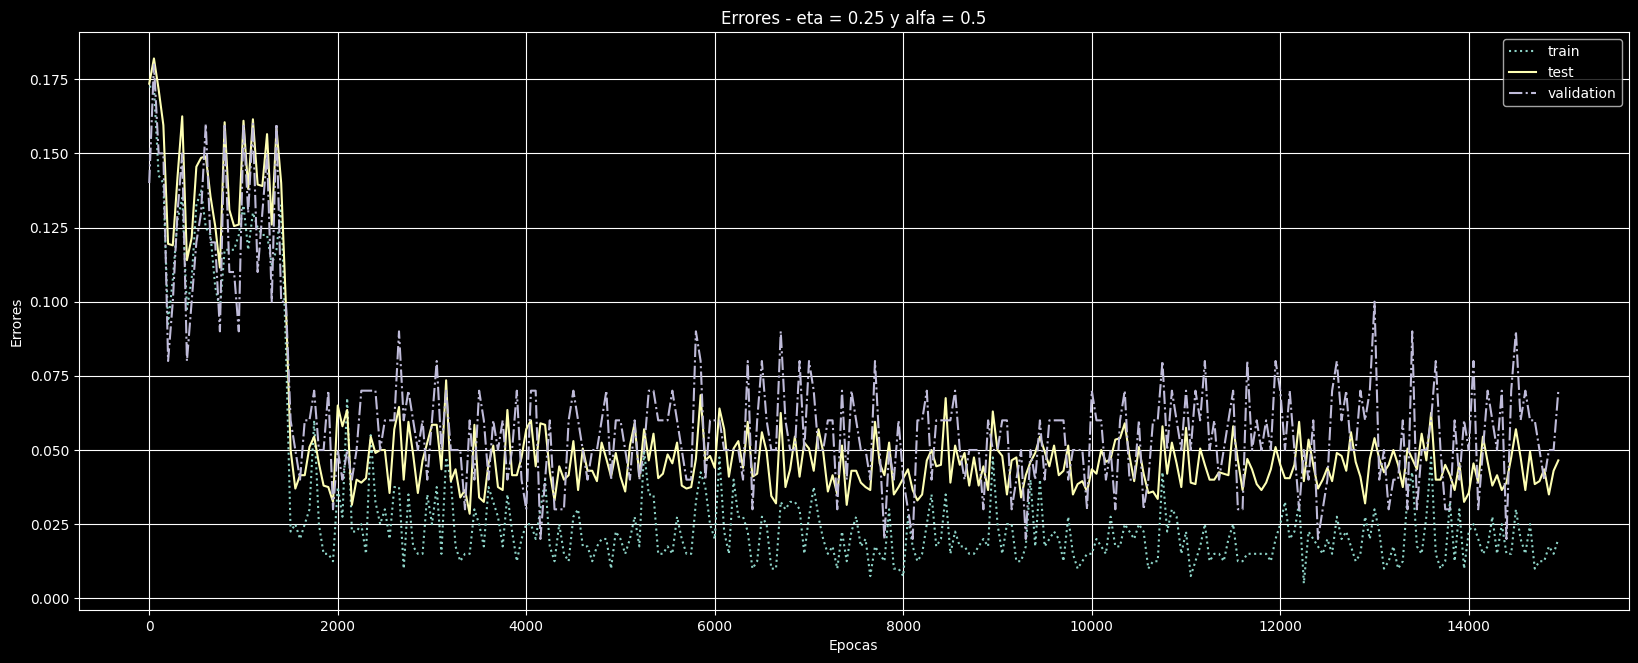

In [ ]:
# Obtenemos el índice de la entrada del menor error promedio de test
_k = table_ej2["Error de testeo promedio"].idxmin()

_find_min_val = []

for _j in range(len(ej2["nns"][_k])):
    _find_min_val.append(ej2["nns"][_k][_j]["e_val"])

_i = _find_min_val.index(min(_find_min_val))

_e_train = ej2["nns"][_k][_i]["e_train"]
_e_val = ej2["nns"][_k][_i]["e_val"]
_e_test = ej2["nns"][_k][_i]["e_test"]

# Ploteamos los errores
_, _ax = plt.subplots(1, 1, sharey=True, figsize=(20, 7.5), squeeze=False)

plot_errors(_ax[0, 0], _e_train,
                _e_test, _e_val,
                ej2["super_epocas"][_k], ej2["sub_epocas"][_k])

_ax[0, 0].set_title(f"Errores - eta = {0.25} y alfa = {0.5}" )
plt.show()

### Conclusión de la gráfica

En la gráfica podemos observar que hay una pequeña diferencia entre el error de entrenamiento y el error de testeo, aunque por lo general se mantiene baja. Por lo que los valores del learning rate y momentum para este problema parecen ser adecuados.

# Ejercicio 3. Regularización

## Entrenamos la red

In [ ]:
def cargar_datos_ej3(val_per):
    # Cargamos los datos
    X, y = cargar_csv('./data/ikeda.data', 5, separator=r'\s+')

    # Spliteamos el training y validacion
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X, y, test_size=val_per)
    return X_train, X_val, y_train, y_val

In [ ]:
def res_ej3(val_perc):
    iter = 10

    # Parámetros
    eta = 0.01             # eta := learning rate
    alfa = 0.9             # alfa := momentum
    sub_epocas = 50        # número de épocas que entrena cada vez
    eval = 400             # número de veces que realizaremos sub-epocas
    # épocas ~= sub_epocas * super_epocas
    N2 = 30     # neuronas en la capa oculta

    # Cargamos los datos de test
    X, y = cargar_csv('./data/ikeda.test', xcols=5, separator=r'\s+')
    # Hacemos el split de testing (~ 2000 datos de train)
    _, X_test, _, y_test = skl.model_selection.train_test_split(X, y, test_size=0.416)

    # Calculamos el porcentaje de datos usado para entrenamiento
    train_perc = 1 - val_perc

    nns = []

    for i in range(iter):
        # Generamos los datos
        X_train, X_val, y_train, y_val = cargar_datos_ej3(val_perc)

        # Defino MLP para regresión
        regr = MLPRegressor(
            hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=eta,
            momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=sub_epocas
        )

        # Corremos el entrenamiento
        regr, e_train, e_val, e_test = entrenar_red_rgr(regr, eval, X_train, y_train, X_val, y_val, X_test, y_test)

        # Guardamos el resultado
        nns.append( {"regr"    : regr,
                     "e_train"   : e_train,
                     "e_val"     : e_val,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "train_perc" : train_perc,
             "val_perc" : val_perc,
             "super_epocas" : eval,
             "sub_epocas" : sub_epocas
           }

Entrenamos la red con distintas distribuciones del conjunto de datos de testeo. Agregamos dos valores extra además de los recomendados.

In [ ]:
_archivo_cache = "resultados_ej3.pkl"

ej3_cases = [0.05, 0.25, 0.5, 0.75, 0.9]

if os.path.exists(_archivo_cache):
    ej3 = joblib.load(_archivo_cache)
else:

    ej3 = {
            "nnss" : [],
            "super_epocas" : [],
            "sub_epocas" : [],
            "train_perc" : [],
            "val_perc" : []
           }
    _res_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej3)(_c) for _c in ej3_cases
    )

    for _res in _res_paralelos:
        ej3["nnss"].append(_res["nns"])
        ej3["train_perc"].append(_res["train_perc"])
        ej3["val_perc"].append(_res["val_perc"])
        ej3["super_epocas"].append(_res["super_epocas"])
        ej3["sub_epocas"].append(_res["sub_epocas"])

    joblib.dump(ej3, _archivo_cache)

## Ploteamos la tabla

Luego de entrenar las redes, mostramos en una tabla los resultados de los entrenamientos. La primer columna muestra el porcentaje de los datos importados de Ikeda que fueron destinados para entrenamiento, la segunda columna muestra el porcentaje de los datos importados de Ikeda que fueron destinados para validación, y la última columna muestra el error promedio de los entrenamientos

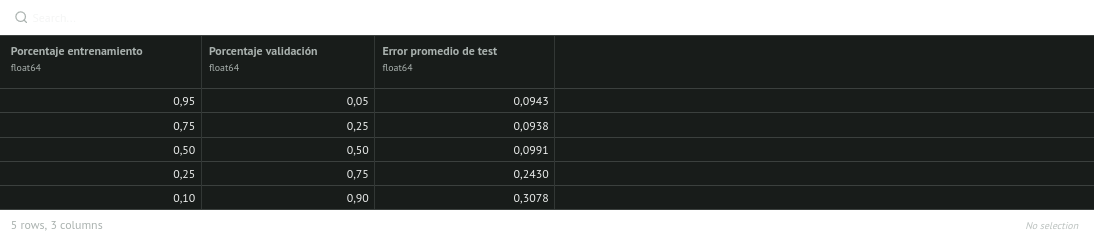

In [ ]:
# Creamos y mostramos la tabla para encontrar la mejor red
_aux_table_ej3 = {
                   "Porcentaje entrenamiento" : [],
                   "Porcentaje validación" : [],
                   "Error promedio de test": [],
                 }

for _i in range(len(ej3["nnss"])):
    _errs_test = []
    for _j in range(len(ej3["nnss"][_i])):
        _min_e_val = min(ej3["nnss"][_i][_j]["e_val"])
        _k = ej3["nnss"][_i][_j]["e_val"].index(_min_e_val)
        _errs_test.append(ej3["nnss"][_i][_j]["e_test"][_k])

    _aux_table_ej3["Error promedio de test"].append(round(np.mean(_errs_test),4))

    _aux_table_ej3["Porcentaje validación"].append(round(ej3["val_perc"][_i],2))
    _aux_table_ej3["Porcentaje entrenamiento"].append(round(ej3["train_perc"][_i],2))

table_ej3 = pd.DataFrame(_aux_table_ej3)
table_ej3

En base a los resultados que aparecen en la tabla, observamos que las tres distribuciones propuestas por el ejercicio arrojaron un error promedio bastante similar. Por otro lado, las proporciones propuestas por nosotros arrojan un error más grande.

## Ploteamos los errores

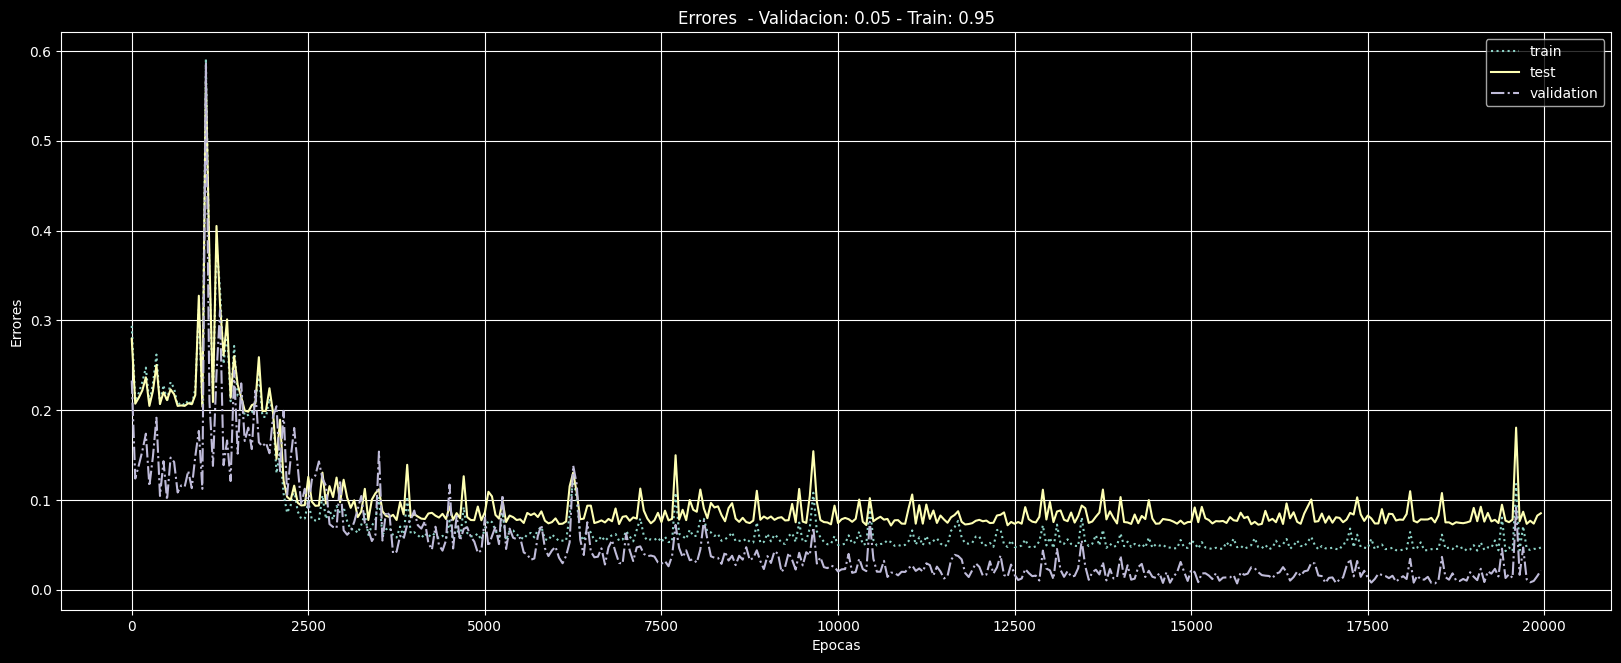

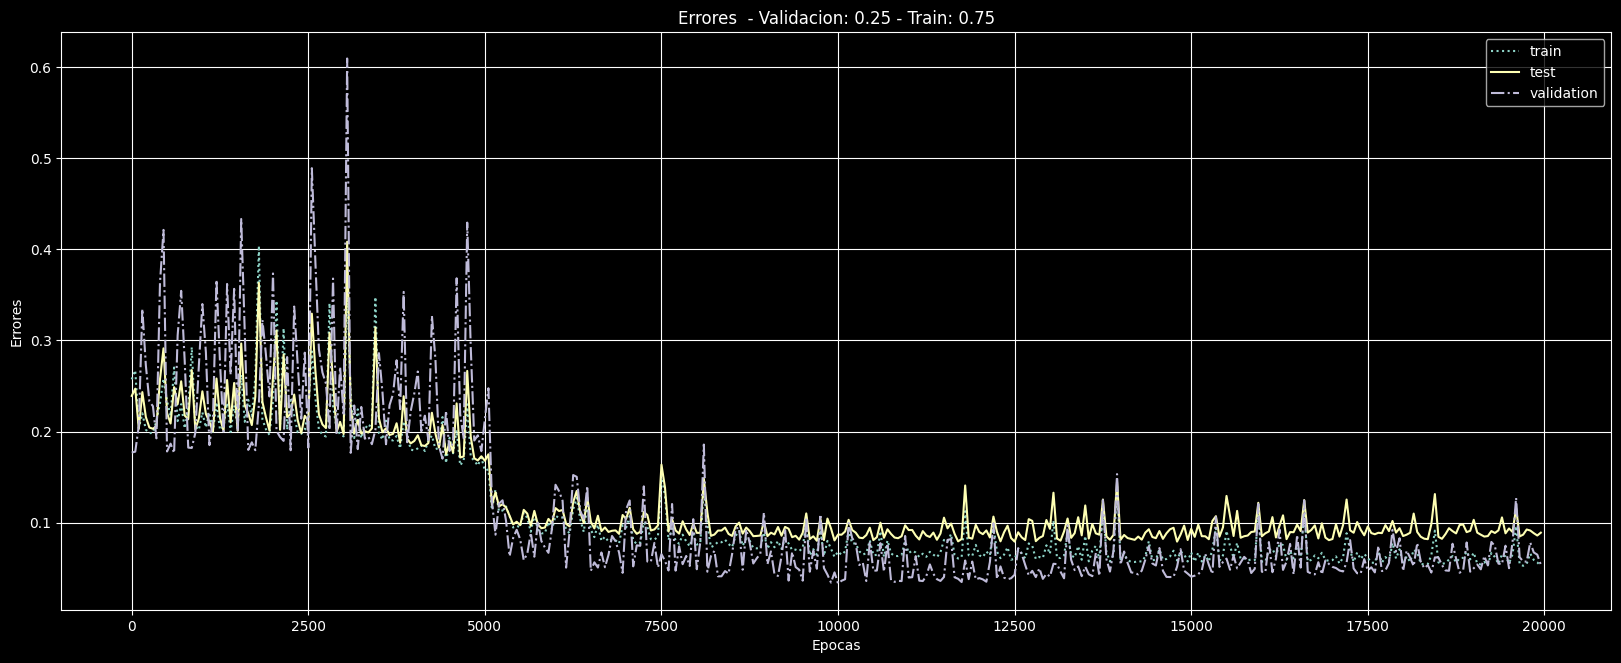

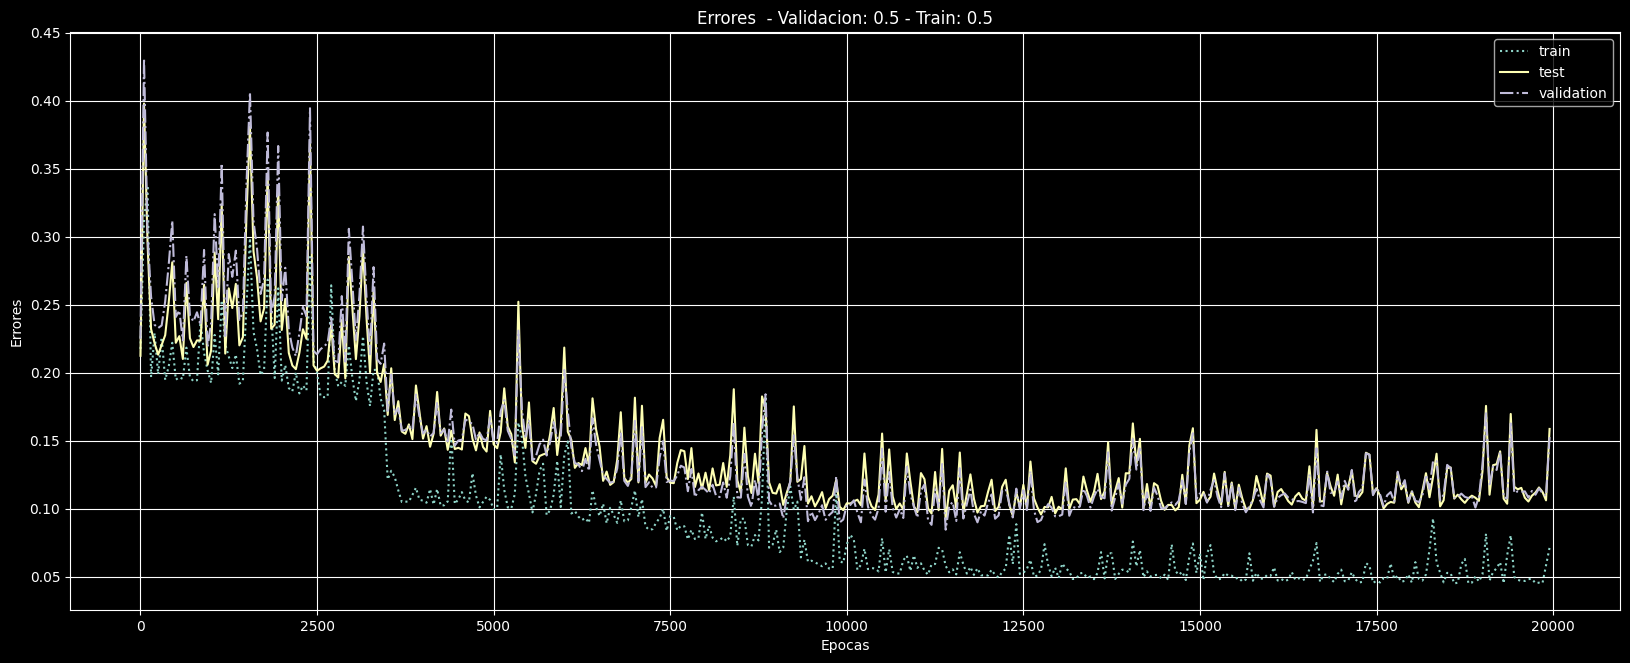

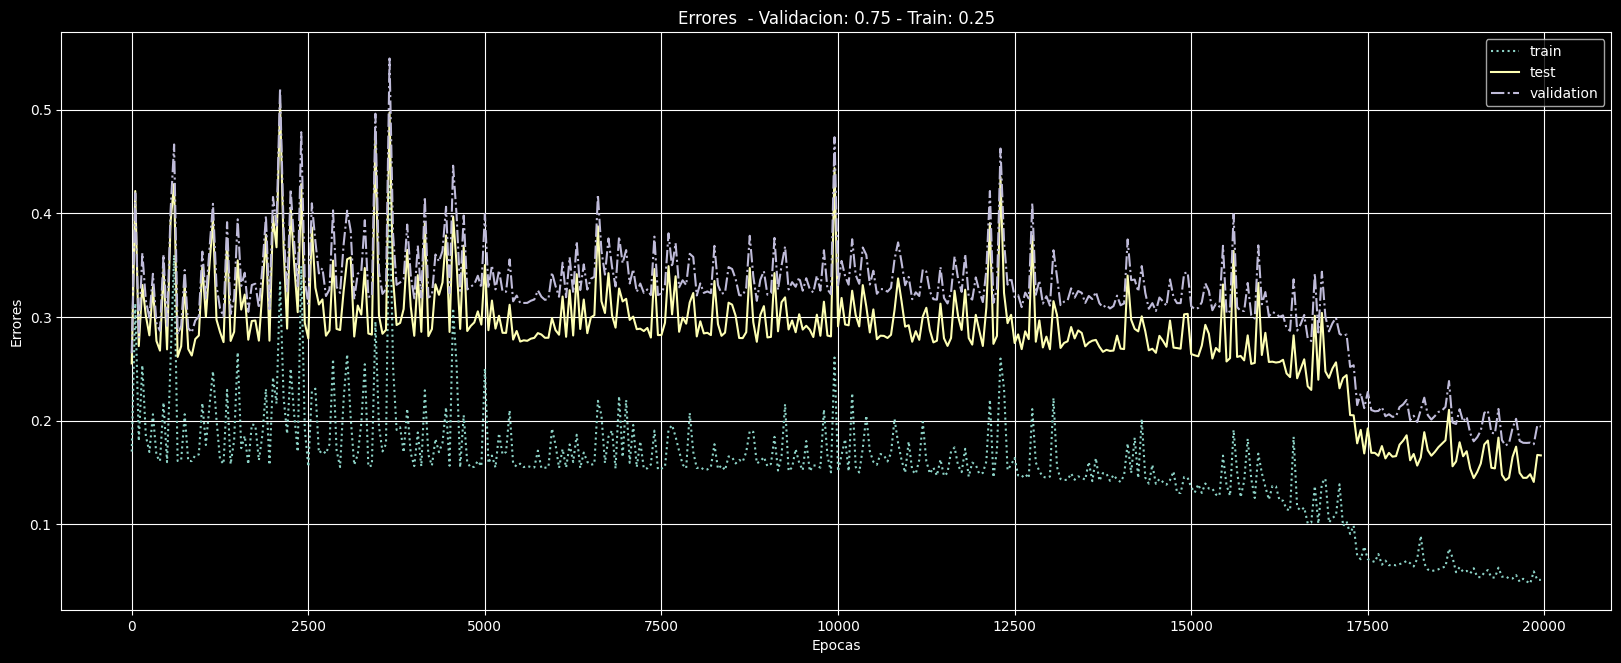

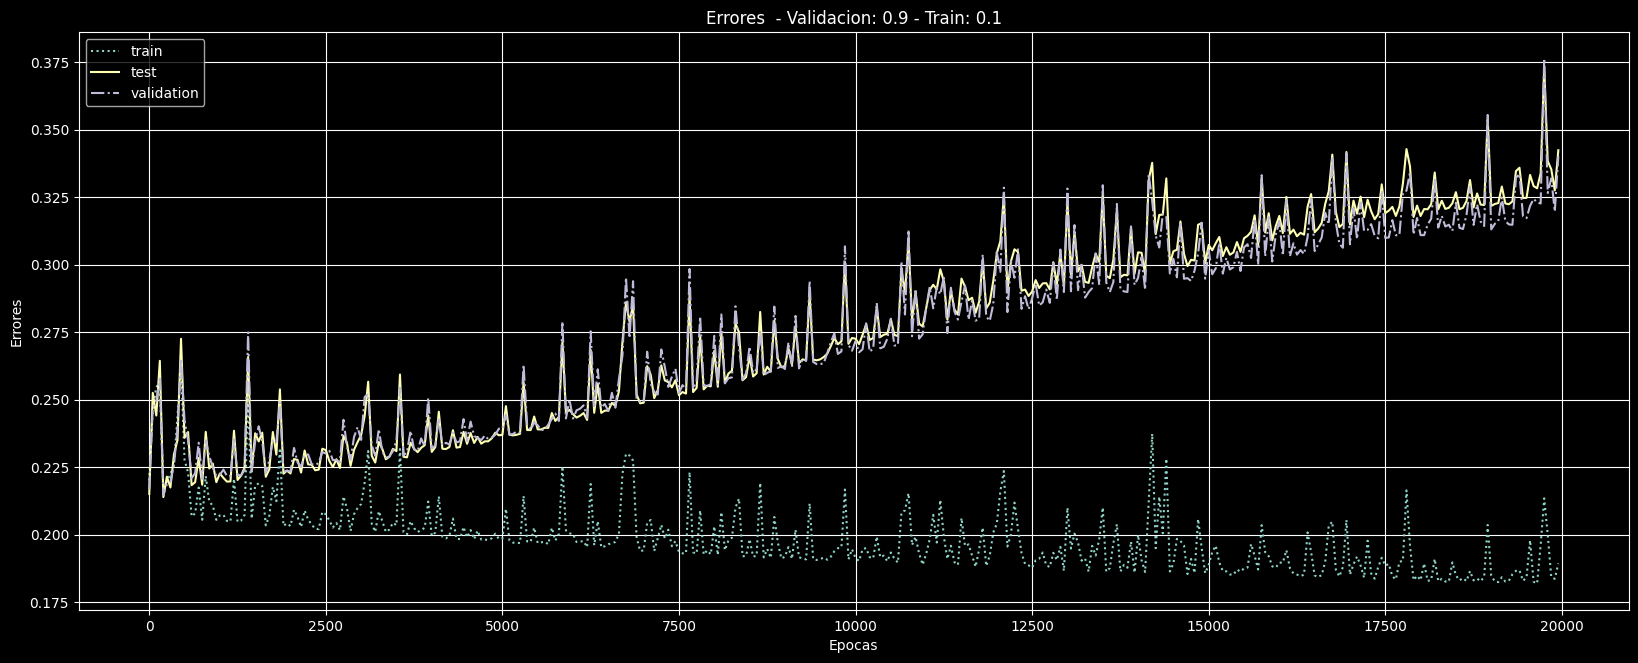

In [ ]:
for _k in range(len(ej3["nnss"])):
    _find_min_val = []

    for _j in range(len(ej3["nnss"][_k])):
        _find_min_val.append(min(ej3["nnss"][_k][_j]["e_val"]))

    _i = _find_min_val.index(min(_find_min_val))

    _e_train = ej3["nnss"][_k][_i]["e_train"]
    _e_val = ej3["nnss"][_k][_i]["e_val"]
    _e_test = ej3["nnss"][_k][_i]["e_test"]

    # Ploteamos los errores
    _, _ax = plt.subplots(1, 1, sharey=True, figsize=(20, 7.5), squeeze=False)

    plot_errors(_ax[0, 0], _e_train,
                    _e_test, _e_val,
                    ej3["super_epocas"][_k], ej3["sub_epocas"][_k])

    _ax[0, 0].set_title(f"Errores  - Validacion: {round(ej3["val_perc"][_k],2)} - Train: {round(ej3["train_perc"][_k],2)}")
    plt.show()

### Conclusiones sobre las gráficas

En general, podemos ver una relación entre la proporciones utilizadas y la época donde se comienzan a estabilizar los errores. En las primeras 4 gráficas podemos ver que mientras más aumenta el porcentaje de datos usados para validación, más tarda en estabilizarse el error. En particular:

- El error de la primer gráfica pareciera converger a partir de la época 2500.

- El error de la segunda gráfica pareciera empezar a estabilizarse a partir de la época 5000.

- El error de la tercer gráfica pareciera converger a partir de la época 10000.

- El error de la cuarte gráfica pareciera que recién comienza a estabilizarse en la época 20000.

En la última gráfica podemos ver overfitting ya que el error de entrenamiento baja y el de test sube. Esto se debe principalmente a que, sin datos no podemos aprender.

Por otra parte, también podemos ver una relación entre las proporciones utilizadas y la distancia entre el error de entrenamiento y el error de testeo. Explícitamente vemos que:

- Cuando se tiene un conjunto de validacion muy chico (primer distribución) puede ocurrir que dicho conjunto tenga datos pocos significativos. Esto puede derivar en que el error de validacion sea poco fiel a la realidad, obteniendo así una red que no generalice de forma correcta (por lo que obtendríamos una brecha entre los errores más grande).

- Si tenemos un conjunto de validacion con una proporcion muy grande (tercer, cuarta y quinta distribución), no nos quedan suficientes datos para aprender. En consecuencia, puede ocurrir que la red no aprenda (ya que no tiene suficientes datos) o bien que aprenda luego de mucho tiempo y que generalice de forma incorrecta (una mayor brecha entre los errores).

En base a todo lo dicho, concluimos que la mejor proporción para los datos de Ikeda es la 75% entrenamiento y 25% validación ya que tiene un error de testeo bajo y además la brecha entre los errores es la más pequeñá.

# Ejercicio 4. Regularización (2).

Recordemos como afecta $\gamma$ a nuestra red.

$\gamma$ es un penalizador. Un escalar que multiplica a la suma de cada peso al cuadrado (o la suma de los valores absolutos de los pesos) e impacta directamente en el error total de la red:

$$\Large{E_{\text{total}} = E_0 + \gamma\sum_{i=1}^{n} w_i^2}$$

Donde $E_0$ representa el error de la red. Esta fórmula fue tomada del libro `Deep Learning` de `Ian Goodfellow`.

En sí este valor representa nuestra preferencia por los pesos grandes. Concretamente (recordemos que en el entrenamiento nos quedamos con la red que tiene menor error total):

- Si el valor de $\gamma$ es igual a 0, el segundo término es igual a cero. Esto nos dice que no tenemos ningun tipo de preferencia por los pesos grandes, por lo tanto no estamos penalizando (no preferimos los pesos grandes ni los chicos).
- Si el valor de $\gamma$ es muy pequeño, el segundo término es muy pequeño. Esto se traduce en una prefencia por los pesos grandes, ya que los pesos no tienen una gran influencia en el error.
- Si el valor de $\gamma$ es muy grande, entonces el segundo término es muy grande. En consecuencia, poseemos una prefencia por los pesos pequeño, ya que el segundo término tiene una gran influencia en el error total.

Tomar un valor muy grande para $\gamma$ no es algo bueno, ya que esto produce underfitting. Tener un valor muy grande de $\gamma$ hace que los pesos sean muy chicos. En consecuencia, cuando las entradas pasan por las conexiones ven que su valor reduce a un número muy cercano a cero. Lo cual no ayuda a la clasificación/regresión.

Por otro lado, un valor muy pequeño para $\gamma$ deriva en que los pesos de la red sean muy elevados. En consecuencia la red se vuelve más compleja. Esto genera overfitting sobre los datos de entrenamientos (pequeñas variaciones en el vector de entrada tendrá grandes implicancias en el resultado).

## Entrenamos las red

In [ ]:
def res_ej4(gamma, ord):
    # ord=1 : Suma de los valores absolutos de los pesos
    # ord=2 : Suma de los cuadrados de los pesos

    iter = 10

    eta = 0.05
    alfa = 0.3
    sub_epocas = 20
    eval = 4000 # "super epocas"
    N2=6

    # Cargamos los datos de test
    X_test, y_test = cargar_csv('./data/ssp.test', 12)

    nns = []

    for i in range(iter):
        # Defino MLP para regresión
        regr = MLPRegressor(hidden_layer_sizes=(N2,), activation='logistic',
                            solver='sgd', alpha=gamma,
                            batch_size=1, learning_rate='constant',
                            learning_rate_init=eta, momentum=alfa,
                            nesterovs_momentum=False, tol=0.0,
                            warm_start=True, max_iter=sub_epocas)

        # Cargamos los datos de entrenamiento
        X_train, y_train = cargar_csv('./data/ssp.data', 12)

        # Corremos el entrenamiento
        regr, e_train, e_test, norm_weight = entrenar_red_wd(regr, eval, gamma, 
                                                              X_train, y_train,
                                                              X_test, y_test,
                                                              ord)
        nns.append( {"regr"    : regr,
                     "e_train"   : e_train,
                     "norm_weight"     : norm_weight,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "ord"  : ord,
             "gamma" : gamma,
             "super_epocas" : eval,
             "sub_epocas" : sub_epocas
           }

Entrenamos algunas redes variando el valor de $\gamma$. Agregamos unos casos extra que nos parecieron interesantes.

In [ ]:
_archivo_cache = "resultados_ej4.pkl"
ej4_cases = [0.00000000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1]

if os.path.exists(_archivo_cache):
    ej4 = joblib.load(_archivo_cache)
else:
    ej4 = { 
            "nnss": [],
            "ord": [],
            "gamma": [],
            "super_epocas": [],
            "sub_epocas": []
          }

    # 1. Ejecutamos todos los casos en paralelo
    _resultados_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej4)(_c, 2) for _c in ej4_cases
    )

    for _res in _resultados_paralelos:
        ej4["nnss"].append(_res["nns"])
        ej4["gamma"].append(_res["gamma"])
        ej4["ord"].append(_res["ord"])
        ej4["super_epocas"].append(_res["super_epocas"])
        ej4["sub_epocas"].append(_res["sub_epocas"])

    joblib.dump(ej4, _archivo_cache)

## Ploteamos una tabla con los resultados

Volcamos sobre una tabla los resultados de los entrenamientos.

In [ ]:
def calc_total_errors(e_trains, norm_weights, gamma, ord):
    e_trains = np.array(e_trains)
    norm_weights = np.array(norm_weights)

    if (ord == 1):
        total_errs = e_trains + gamma * norm_weights
    else: 
        total_errs = e_trains + gamma * (norm_weights * norm_weights)

    return total_errs.tolist()

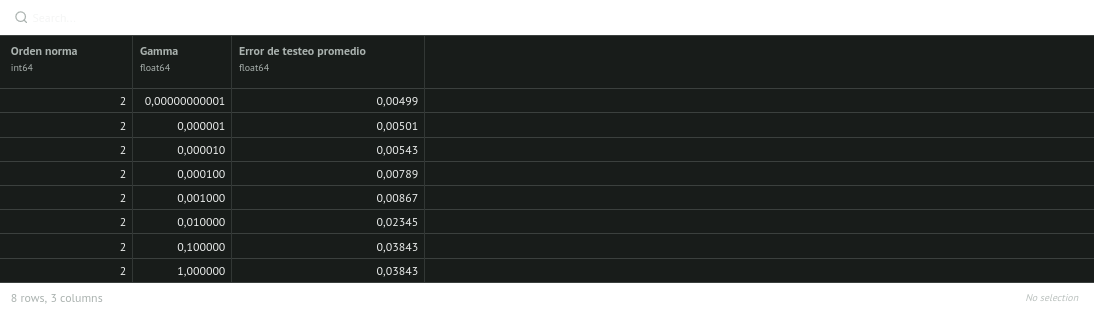

In [ ]:
# Creamos y mostramos la tabla para encontrar la mejor red
_aux_table_ej4 = {
                   "Orden norma" : [],
                   "Gamma" : [],
                   "Error de testeo promedio": []
                 }

_total_errors = []

for _i in range(len(ej4["nnss"])):
    # _min_total_errs = []
    _errs_test = []
    # _errs_train = []

    for _j in range(len(ej4["nnss"][_i])):
        _total_errors = calc_total_errors(ej4["nnss"][_i][_j]["e_train"], 
                                         ej4["nnss"][_i][_j]["norm_weight"],
                                         ej4["gamma"][_i],
                                         ej4["ord"][_i])
        _min_total_err = min(_total_errors)
        _k = _total_errors.index(_min_total_err)
        _errs_test.append(ej4["nnss"][_i][_j]["e_test"][_k])

    _aux_table_ej4["Error de testeo promedio"].append(round(np.mean(_errs_test),5))
    _aux_table_ej4["Gamma"].append(ej4["gamma"][_i])
    _aux_table_ej4["Orden norma"].append(round(ej4["ord"][_i], 2))

table_ej4 = pd.DataFrame(_aux_table_ej4)
table_ej4

Podemos notar que a partir de $\gamma=10^{-6}$, se obtuvo un error menor o igual $0.008$, Mientras que para los valores de $\gamma$ mayores a $10^{-3}$ vemos un error mayor o igual al $0.02$.

## Gráfica $\gamma$-error

Grafiquemos los errores de entrenamiento y error para los distintos valores de gamma:

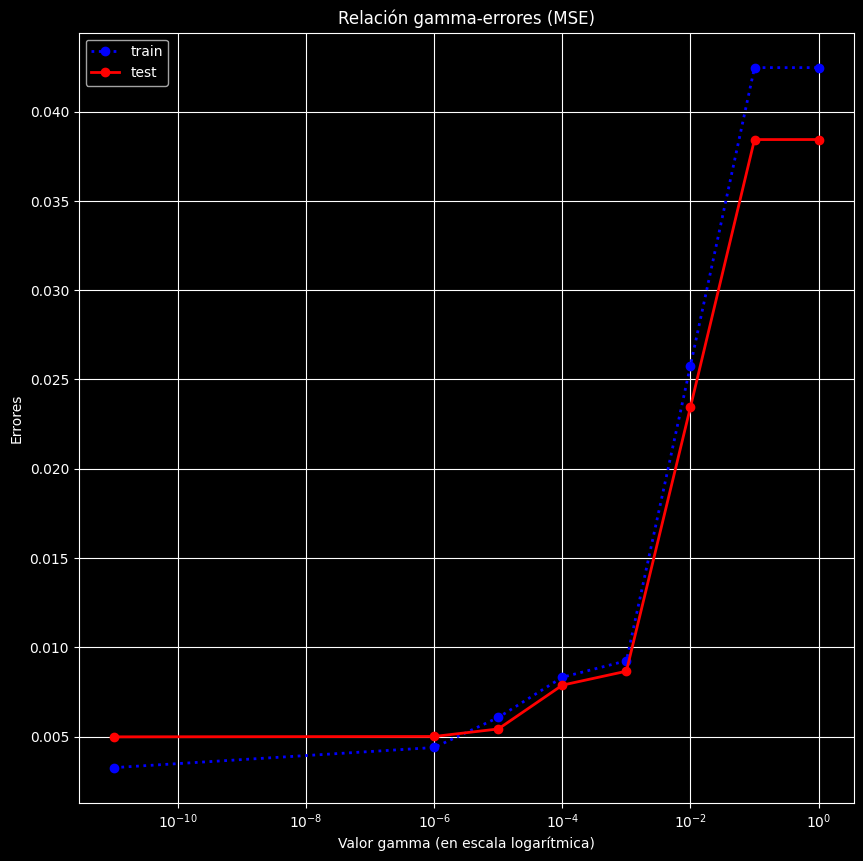

In [ ]:
# Creamos y mostramos la tabla para encontrar la mejor red
_aux_table_ej4_2 = {
                   "ord" : [],
                   "gamma" : [],
                   "avg_e_test": [],
                   "avg_e_train": []
                 }

_total_errors = []

for _i in range(len(ej4["nnss"])):
    # _min_total_errs = []
    _errs_test = []
    _errs_train = []

    for _j in range(len(ej4["nnss"][_i])):
        _total_errors = calc_total_errors(ej4["nnss"][_i][_j]["e_train"], 
                                         ej4["nnss"][_i][_j]["norm_weight"],
                                         ej4["gamma"][_i],
                                         ej4["ord"][_i])
        _min_total_err = min(_total_errors)
        # _min_total_errs.append(_min_total_err)

        _k = _total_errors.index(_min_total_err)
        _errs_train.append(ej4["nnss"][_i][_j]["e_train"][_k])
        _errs_test.append(ej4["nnss"][_i][_j]["e_test"][_k])

    _aux_table_ej4_2["avg_e_test"].append(np.mean(_errs_test))
    _aux_table_ej4_2["avg_e_train"].append(np.mean(_errs_train))

    _aux_table_ej4_2["gamma"].append(ej4["gamma"][_i])
    _aux_table_ej4_2["ord"].append(ej4["ord"][_i])


# Ploteamos los errores
_, _ax = plt.subplots(1, 1, sharey=True, figsize=(10, 10), squeeze=False)

# graficar...

plot_error_wd(_ax[0,0], _aux_table_ej4_2["avg_e_train"], _aux_table_ej4_2["avg_e_test"], ej4_cases)
_ax[0,0].set_title(f"Relación gamma-errores (MSE)")

plt.show()

Observamos que el comportamiento del valor de $\gamma$ con respecto al error de nuestro problema se coindice con lo analizado al comienzo del ejercicio. Un valor muy pequeño de $\gamma$ produce overfitting ($10^{-11}$ y $10^{-6}$). Por otro lado, los valores más grandes de $\gamma$ producen underfitting ($10^{-1}$ y $10^{0}$).

A partir de este análisis, determinamos que el valor óptimo de $\gamma$ es $10^{-5}$. Por otra parte, elegimos el valor $\gamma=10^{-11}$ como el valor de $\gamma$ donde vemos overfitting.

## Ploteamos los errores

In [ ]:
_best_gamma = 10**(-5)
_overfitting_gamma = 10**(-11)

# Indices de los gammas
_bi = ej4["gamma"].index(_best_gamma)
_oi = ej4["gamma"].index(_overfitting_gamma)

# Lista de gammas
gammas = [_bi, _oi]

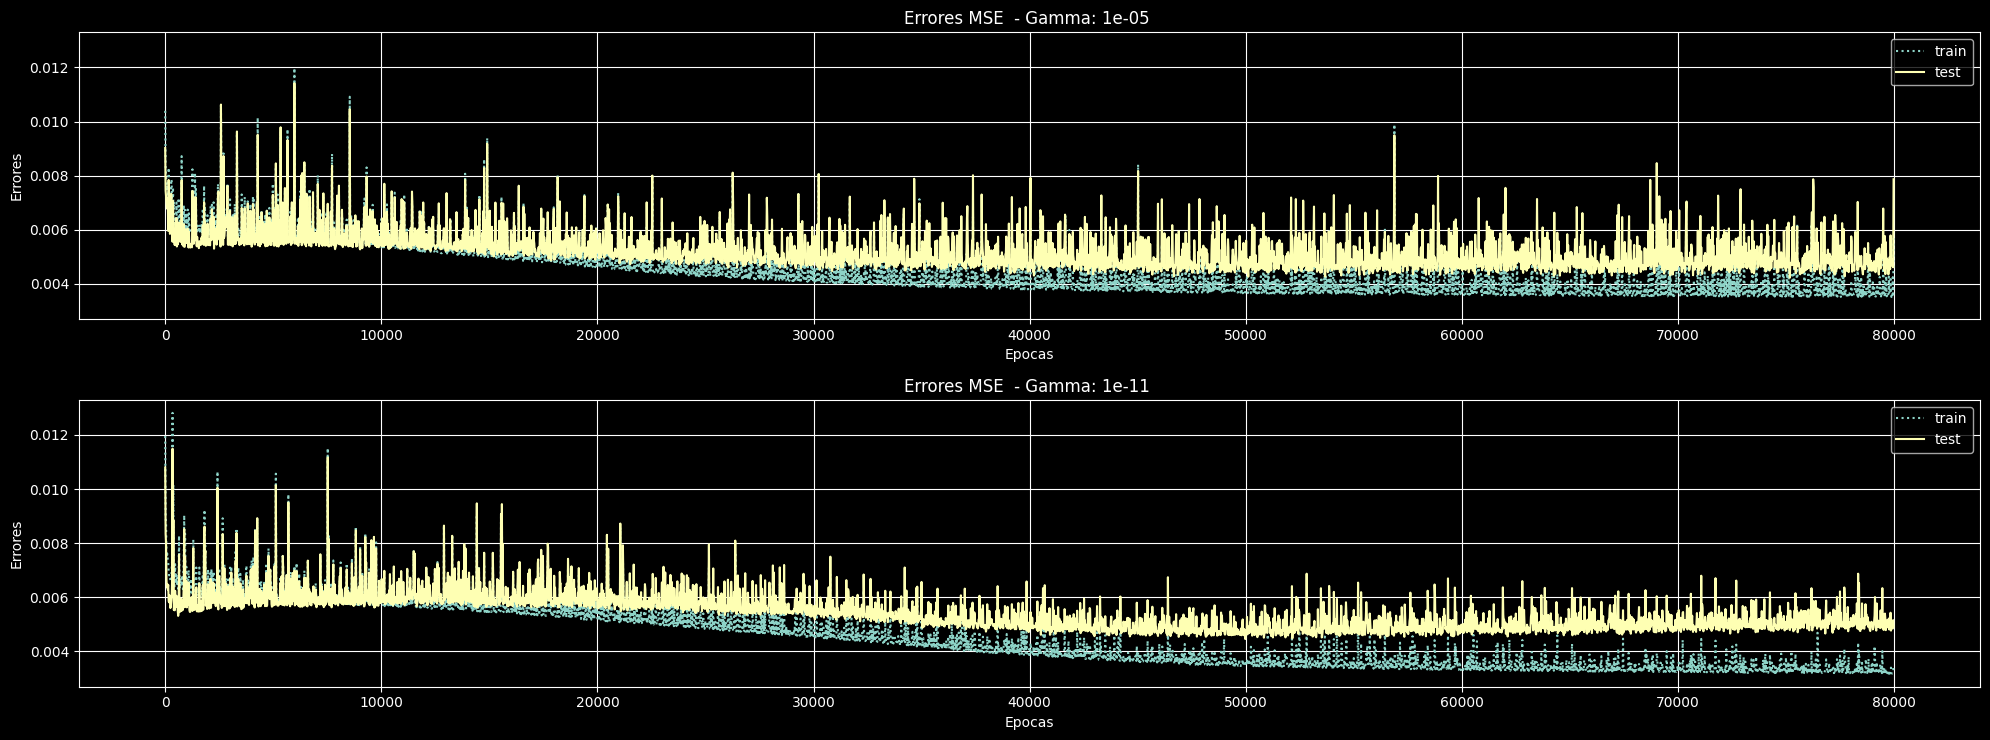

In [ ]:
# GRÁFICA DE LOS ERRORES
_, _ax = plt.subplots(len(gammas), 1, sharey=True, figsize=(20, 7.5), squeeze=False)

_cont = 0

for _i in gammas:
    # Lista de los errores totales mínimos de cada época
    _min_errors = []

    # Nos quedamos con la mejor red para el parámetro 'best_gamma'
    for _j in range(len(ej4["nnss"][_i])):
        # Obtengo la lista de errores de test
        _e_train = ej4["nnss"][_i][_j]["e_train"]

        # Obtenemos la norma de los pesos
        _norm_weights = ej4["nnss"][_i][_j]["norm_weight"]

        # Obtenemos el orden de la norma
        _ord = ej4["ord"][_i]

        # Obtenemos el gamma
        _gamma = ej4["gamma"][_i]

        # Calculamos el error total mínimo de entre todas las épocas
        _min_errors.append(min(calc_total_errors(_e_train, _norm_weights, _gamma, _ord)))

    # Obtenemos el índice
    _k = _min_errors.index(min(_min_errors))

    # Nos quedamos con la red asociada a ese valor, y la ploteamos
    _nn = ej4["nnss"][_i][_k]

    plot_errors_wd(_ax[_cont,0], _nn["e_train"], _nn["e_test"], ej4["super_epocas"][_i], ej4["sub_epocas"][_i])

    _ax[_cont, 0].set_title(f"Errores MSE  - Gamma: {ej4["gamma"][_i]} ")

    _cont += 1

plt.tight_layout()
plt.show()

Tal y como habíamos previsto anteriormente, en la gráfica para $\gamma=10^{-5}$ se ve una muy buena generalización. Por otro lado, apra $\gamma=10^{-11}$ vemos que hay overfitting (el error de testeo pareciera comenzar a crecer de a poco, mientras que el error de entrenamiento comienza a bajar de a poco).

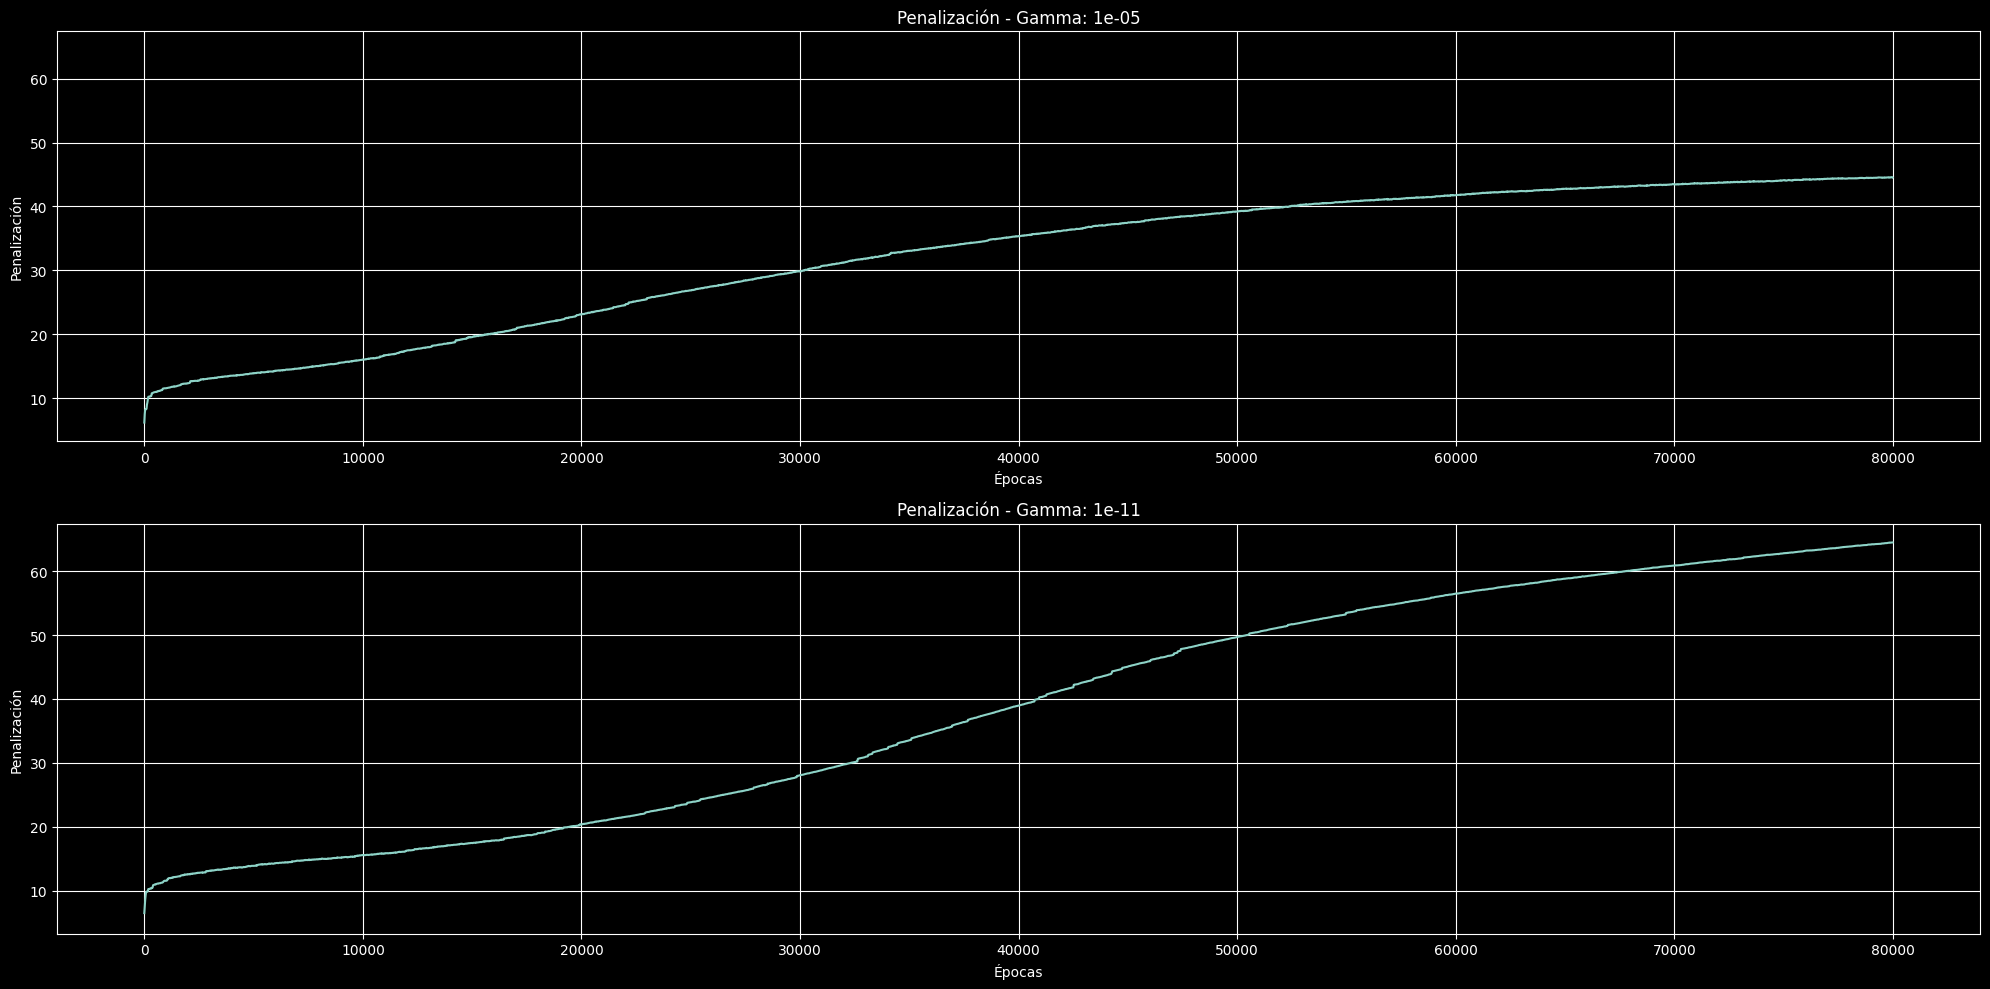

In [ ]:
# GRÁFICA DE LA PENALIZACIÓN
_, _ax = plt.subplots(len(gammas), 1, sharey=True, figsize=(20, 10), squeeze=False)

_cont = 0

for _i in gammas:
    # Lista de los errores totales mínimos de cada época
    _min_errors = []

    # Nos quedamos con la mejor red para el parámetro 'best_gamma'
    for _j in range(len(ej4["nnss"][_i])):
        # Obtengo la lista de errores de train
        _e_train = ej4["nnss"][_i][_j]["e_train"]

        # Obtenemos la norma de los pesos
        _norm_weights = ej4["nnss"][_i][_j]["norm_weight"]

        # Obtenemos el orden de la norma
        _ord = ej4["ord"][_i]

        # Obtenemos el gamma
        _gamma = ej4["gamma"][_i]

        # Calculamos el error total mínimo de entre todas las épocas
        _min_errors.append(min(calc_total_errors(_e_train, _norm_weights, _gamma, _ord)))

    # Obtenemos el índice
    _k = _min_errors.index(min(_min_errors))

    # Nos quedamos con la red asociada a ese valor, y la ploteamos
    _nn = ej4["nnss"][_i][_k]

    plot_penalization(_ax[_cont,0], _nn["norm_weight"], ej4["super_epocas"][_i], ej4["sub_epocas"][_i])

    _ax[_cont, 0].set_title(f"Penalización - Gamma: {ej4["gamma"][_i]}")
    _cont += 1

plt.tight_layout()
plt.show()

Nuevamente, estas gráficas parecen coincidir con nuestro análisis hecho al inicio del ejercicio. Observamos que el valor más grande de $\gamma$ tiene una mayor penzalización que el valor más pequeño de $\gamma$.

# Ejercicio 5. Dimensionalidad.

## Entrenamos las redes

In [ ]:
# Importamos los generadores de datos (Paralelas y Diagonales)
from diagonal import diagonales
from paralelas import paralelas

In [ ]:
def res_ej5(N2, d, eta, alfa, gamma, ord, super_epocas, sub_epocas, gen="paral"):
    # Parámetros:
    # d := Dimensiones de los datos generados
    # N2 := neuronas en la capa oculta
    # eta := learning rate
    # alfa := momentum
    # gamma := weight decay parameter
    # ord := normalización utilizada en los pesos
    # número de épocas que entrena cada vez
    # número de veces que realizaremos sub-epocas
    # épocas ~= sub_epocas * super_epocas
    # gen := Generador de datos gen="diag" para diagonales (default paralelas)


    generator = paralelas

    if (gen == "diag"):
        generator = diagonales


    iter = 20

    test_size = 10000
    train_size = 250
    C = 0.78 

    nns = []

    # Generamos los datos de test
    test_data = generator(d, C, test_size) 
    X_test, y_test = np.vstack(test_data.input.values), test_data.output

    for i in range(iter):
        # Generamos los datos de entrenamiento y validación
        train_data = generator(d, C, train_size) 
        X_train, y_train = np.vstack(train_data.input.values), train_data.output

        # Defino MLP para clasificación
        classf = MLPClassifier(hidden_layer_sizes=(N2,), activation='logistic',
                            solver='sgd', alpha=gamma,
                            batch_size=1, learning_rate='constant',
                            learning_rate_init=eta, momentum=alfa,
                            nesterovs_momentum=False, tol=0.0,
                            warm_start=True, max_iter=sub_epocas)

        # Corremos el entrenamiento
        classf, e_train, e_test, norm_weight = entrenar_red_wd_clasf(classf, super_epocas, gamma, 
                                                              X_train, y_train,
                                                              X_test, y_test,
                                                              ord)
        nns.append( {"classf"    : classf,
                     "e_train"   : e_train,
                     "norm_weight"     : norm_weight,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "d" : d,
             "neurons" : N2, 
             "learning_rate" : eta,
             "momentum" : alfa,
             "gamma" : gamma,
             "ord"  : ord,
             "super_epocas" : super_epocas,
             "sub_epocas" : sub_epocas
           }

In [ ]:
# Definimos las dimensiones
dimensions_ej5 = [2, 4, 8, 16, 32]

Entrenamos la red con los hiper-parámetros que nos parecieron convenientes (que nos fueron dando buenos resultado en otras ejecuciones). Lo que si tuvimos que hacer es bajar la cantidad de evaluaciones (super épocas) ya que tardaba mucho en entrenar la red.

In [ ]:
_archivo_cache = "resultados_ej5_paral.pkl"

ej5_paral_cases = []

for _d in dimensions_ej5:
    ej5_paral_cases.append((6, _d, 0.25, 0.5, 10**(-5), 2, 400, 20))


if os.path.exists(_archivo_cache):
    ej5_paral = joblib.load(_archivo_cache)
else:

    ej5_paral = {
             "nnss" : [],
             "d" : [],
             "neurons" : [],
             "learning_rate" : [],
             "momentum" : [],
             "gamma" : [],
             "ord" : [],
             "super_epocas" : [],
             "sub_epocas" : []
           }

    _res_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej5)(_N2, _d, _eta, _alfa, _gamma, _ord, _super_epocas, _sub_epocas) for _N2, _d, _eta, _alfa, _gamma, _ord, _super_epocas, _sub_epocas in ej5_paral_cases
    )

    for _res in _res_paralelos:
        ej5_paral["nnss"].append(_res["nns"])
        ej5_paral["d"].append(_res["d"])
        ej5_paral["neurons"].append(_res["neurons"])
        ej5_paral["learning_rate"].append(_res["learning_rate"])
        ej5_paral["momentum"].append(_res["momentum"])
        ej5_paral["gamma"].append(_res["gamma"])
        ej5_paral["ord"].append(_res["ord"])
        ej5_paral["super_epocas"].append(_res["super_epocas"])
        ej5_paral["sub_epocas"].append(_res["sub_epocas"])


    joblib.dump(ej5_paral, _archivo_cache)

In [ ]:
_archivo_cache = "resultados_ej5_diag.pkl"

ej5_diag_cases = []

for _d in dimensions_ej5:
    ej5_diag_cases.append((6, _d, 0.25, 0.5, 10**(-5), 2, 400, 20))

if os.path.exists(_archivo_cache):
    ej5_diag = joblib.load(_archivo_cache)
else:

    ej5_diag = {
             "nnss" : [],
             "d" : [],
             "neurons" : [],
             "learning_rate" : [],
             "momentum" : [],
             "gamma" : [],
             "ord" : [],
             "super_epocas" : [],
             "sub_epocas" : []
           }

    _res_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej5)(_N2, _d, _eta, _alfa, _gamma, _ord, _super_epocas, _sub_epocas, gen="diag") for _N2, _d, _eta, _alfa, _gamma, _ord, _super_epocas, _sub_epocas in ej5_diag_cases
    )

    for _res in _res_paralelos:
        ej5_diag["nnss"].append(_res["nns"])
        ej5_diag["d"].append(_res["d"])
        ej5_diag["neurons"].append(_res["neurons"])
        ej5_diag["learning_rate"].append(_res["learning_rate"])
        ej5_diag["momentum"].append(_res["momentum"])
        ej5_diag["gamma"].append(_res["gamma"])
        ej5_diag["ord"].append(_res["ord"])
        ej5_diag["super_epocas"].append(_res["super_epocas"])
        ej5_diag["sub_epocas"].append(_res["sub_epocas"])


    joblib.dump(ej5_diag, _archivo_cache)

## Ploteamos la tabla y los errores

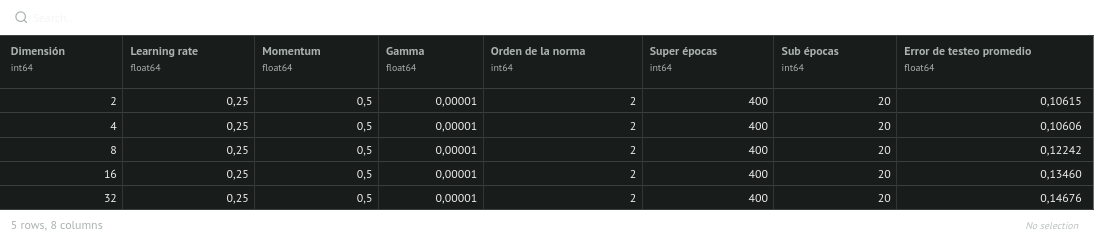

In [ ]:
# Creamos y mostramos la tabla para encontrar la mejor red
_aux_table_ej5 = {
                   "Dimensión" : [],
                   "Learning rate" : [],
                   "Momentum" : [],
                   "Gamma" : [],
                   "Orden de la norma" : [],
                   "Super épocas" : [],
                   "Sub épocas" : [],
                   "Error de testeo promedio": [],
                 }

for _i in range(len(ej5_paral["nnss"])):
    _errs_test = []
    for _j in range(len(ej5_paral["nnss"][_i])):
        _total_errors = calc_total_errors(ej5_paral["nnss"][_i][_j]["e_train"], 
                                         ej5_paral["nnss"][_i][_j]["norm_weight"],
                                         ej5_paral["gamma"][_i],
                                         ej5_paral["ord"][_i])
        _min_total_err = min(_total_errors)
        _k = _total_errors.index(_min_total_err)
        _errs_test.append(ej5_paral["nnss"][_i][_j]["e_test"][_k])

    _aux_table_ej5["Error de testeo promedio"].append(round(np.mean(_errs_test),5))
    _aux_table_ej5["Dimensión"].append(ej5_paral["d"][_i])
    _aux_table_ej5["Learning rate"].append(ej5_paral["learning_rate"][_i])
    _aux_table_ej5["Momentum"].append(ej5_paral["momentum"][_i])
    _aux_table_ej5["Gamma"].append(ej5_paral["gamma"][_i])
    _aux_table_ej5["Orden de la norma"].append(ej5_paral["ord"][_i])
    _aux_table_ej5["Super épocas"].append(ej5_paral["super_epocas"][_i])
    _aux_table_ej5["Sub épocas"].append(ej5_paral["sub_epocas"][_i])

table_ej5_paral = pd.DataFrame(_aux_table_ej5)
table_ej5_paral

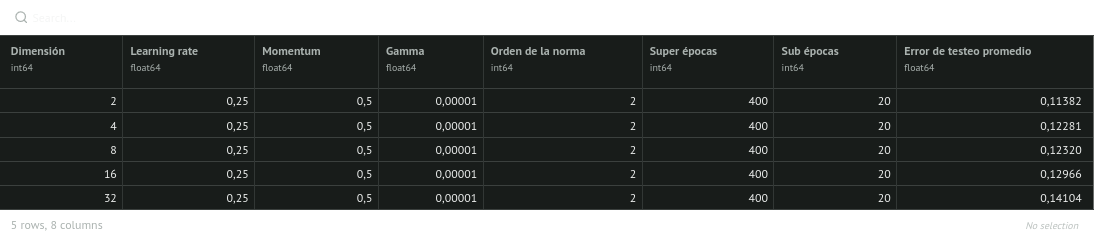

In [ ]:
# Creamos y mostramos la tabla para encontrar la mejor red
_aux_table_ej5 = {
                   "Dimensión" : [],
                   "Learning rate" : [],
                   "Momentum" : [],
                   "Gamma" : [],
                   "Orden de la norma" : [],
                   "Super épocas" : [],
                   "Sub épocas" : [],
                   "Error de testeo promedio": [],
                 }

for _i in range(len(ej5_diag["nnss"])):
    _errs_test = []
    for _j in range(len(ej5_diag["nnss"][_i])):
        _total_errors = calc_total_errors(ej5_diag["nnss"][_i][_j]["e_train"], 
                                         ej5_diag["nnss"][_i][_j]["norm_weight"],
                                         ej5_diag["gamma"][_i],
                                         ej5_diag["ord"][_i])
        _min_total_err = min(_total_errors)
        _k = _total_errors.index(_min_total_err)
        _errs_test.append(ej5_diag["nnss"][_i][_j]["e_test"][_k])

    _aux_table_ej5["Error de testeo promedio"].append(round(np.mean(_errs_test),5))
    _aux_table_ej5["Dimensión"].append(ej5_diag["d"][_i])
    _aux_table_ej5["Learning rate"].append(ej5_diag["learning_rate"][_i])
    _aux_table_ej5["Momentum"].append(ej5_diag["momentum"][_i])
    _aux_table_ej5["Gamma"].append(ej5_diag["gamma"][_i])
    _aux_table_ej5["Orden de la norma"].append(ej5_diag["ord"][_i])
    _aux_table_ej5["Super épocas"].append(ej5_diag["super_epocas"][_i])
    _aux_table_ej5["Sub épocas"].append(ej5_diag["sub_epocas"][_i])

table_ej5_diag = pd.DataFrame(_aux_table_ej5)
table_ej5_diag

## Graficamos los errores con paralelas

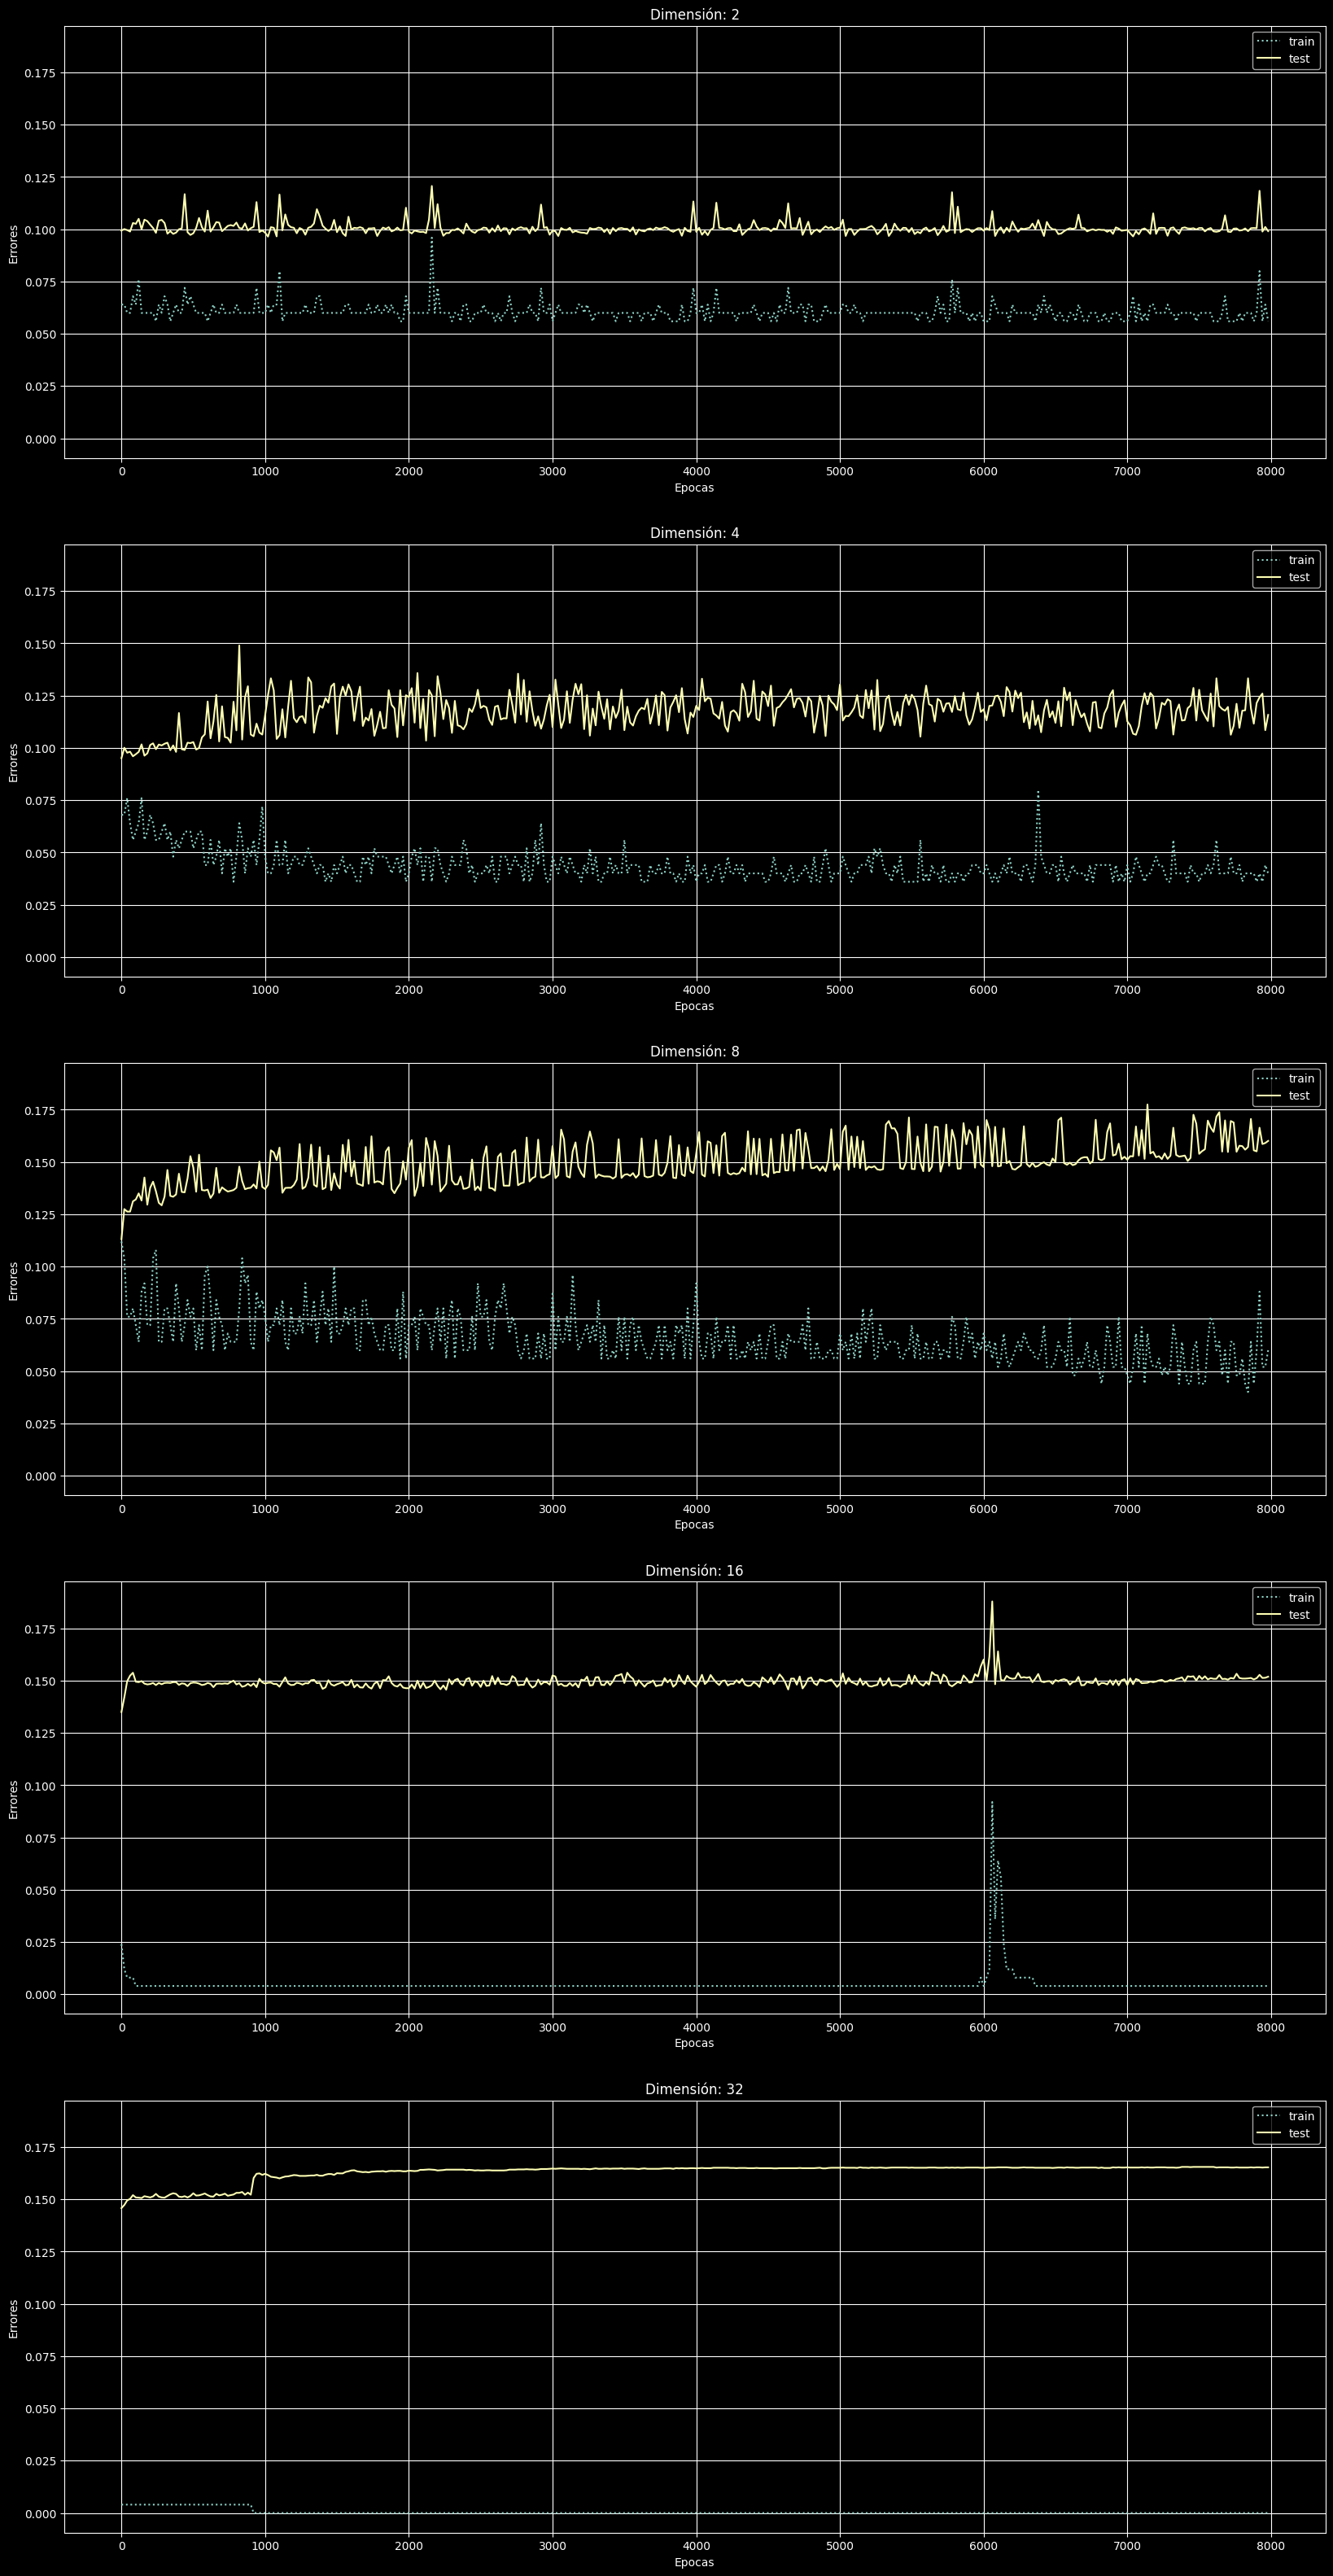

In [ ]:
# GRÁFICA DE LOS ERRORES PARALELAS
_, _ax = plt.subplots(len(dimensions_ej5), 1, sharey=True, figsize=(20, 40), squeeze=False)

_cont = 0

for _d in range(len(dimensions_ej5)):
    # Lista de los errores totales mínimos de cada época
    _min_errors = []

    # Nos quedamos con la mejor red para el parámetro 'best_gamma'
    for _j in range(len(ej5_paral["nnss"][_d])):
        # Obtengo la lista de errores de test
        _e_train = ej5_paral["nnss"][_d][_j]["e_train"]

        # Obtenemos la norma de los pesos
        _norm_weights = ej5_paral["nnss"][_d][_j]["norm_weight"]

        # Obtenemos el orden de la norma
        _ord = ej5_paral["ord"][_d]

        # Obtenemos el gamma
        _gamma = ej5_paral["gamma"][_d]

        # Calculamos el error total mínimo de entre todas las épocas
        _min_errors.append(min(calc_total_errors(_e_train, _norm_weights, _gamma, _ord)))

    # Obtenemos el índice
    _k = _min_errors.index(min(_min_errors))

    # Nos quedamos con la red asociada a ese valor, y la ploteamos
    _nn = ej5_paral["nnss"][_d][_k]

    plot_errors_wd(_ax[_cont,0], _nn["e_train"], _nn["e_test"], ej5_paral["super_epocas"][_d], ej5_paral["sub_epocas"][_d])

    _ax[_d, 0].set_title(f"Dimensión: {dimensions_ej5[_d]}")

    _cont += 1

plt.show()

## Graficamos los errores con diagonales

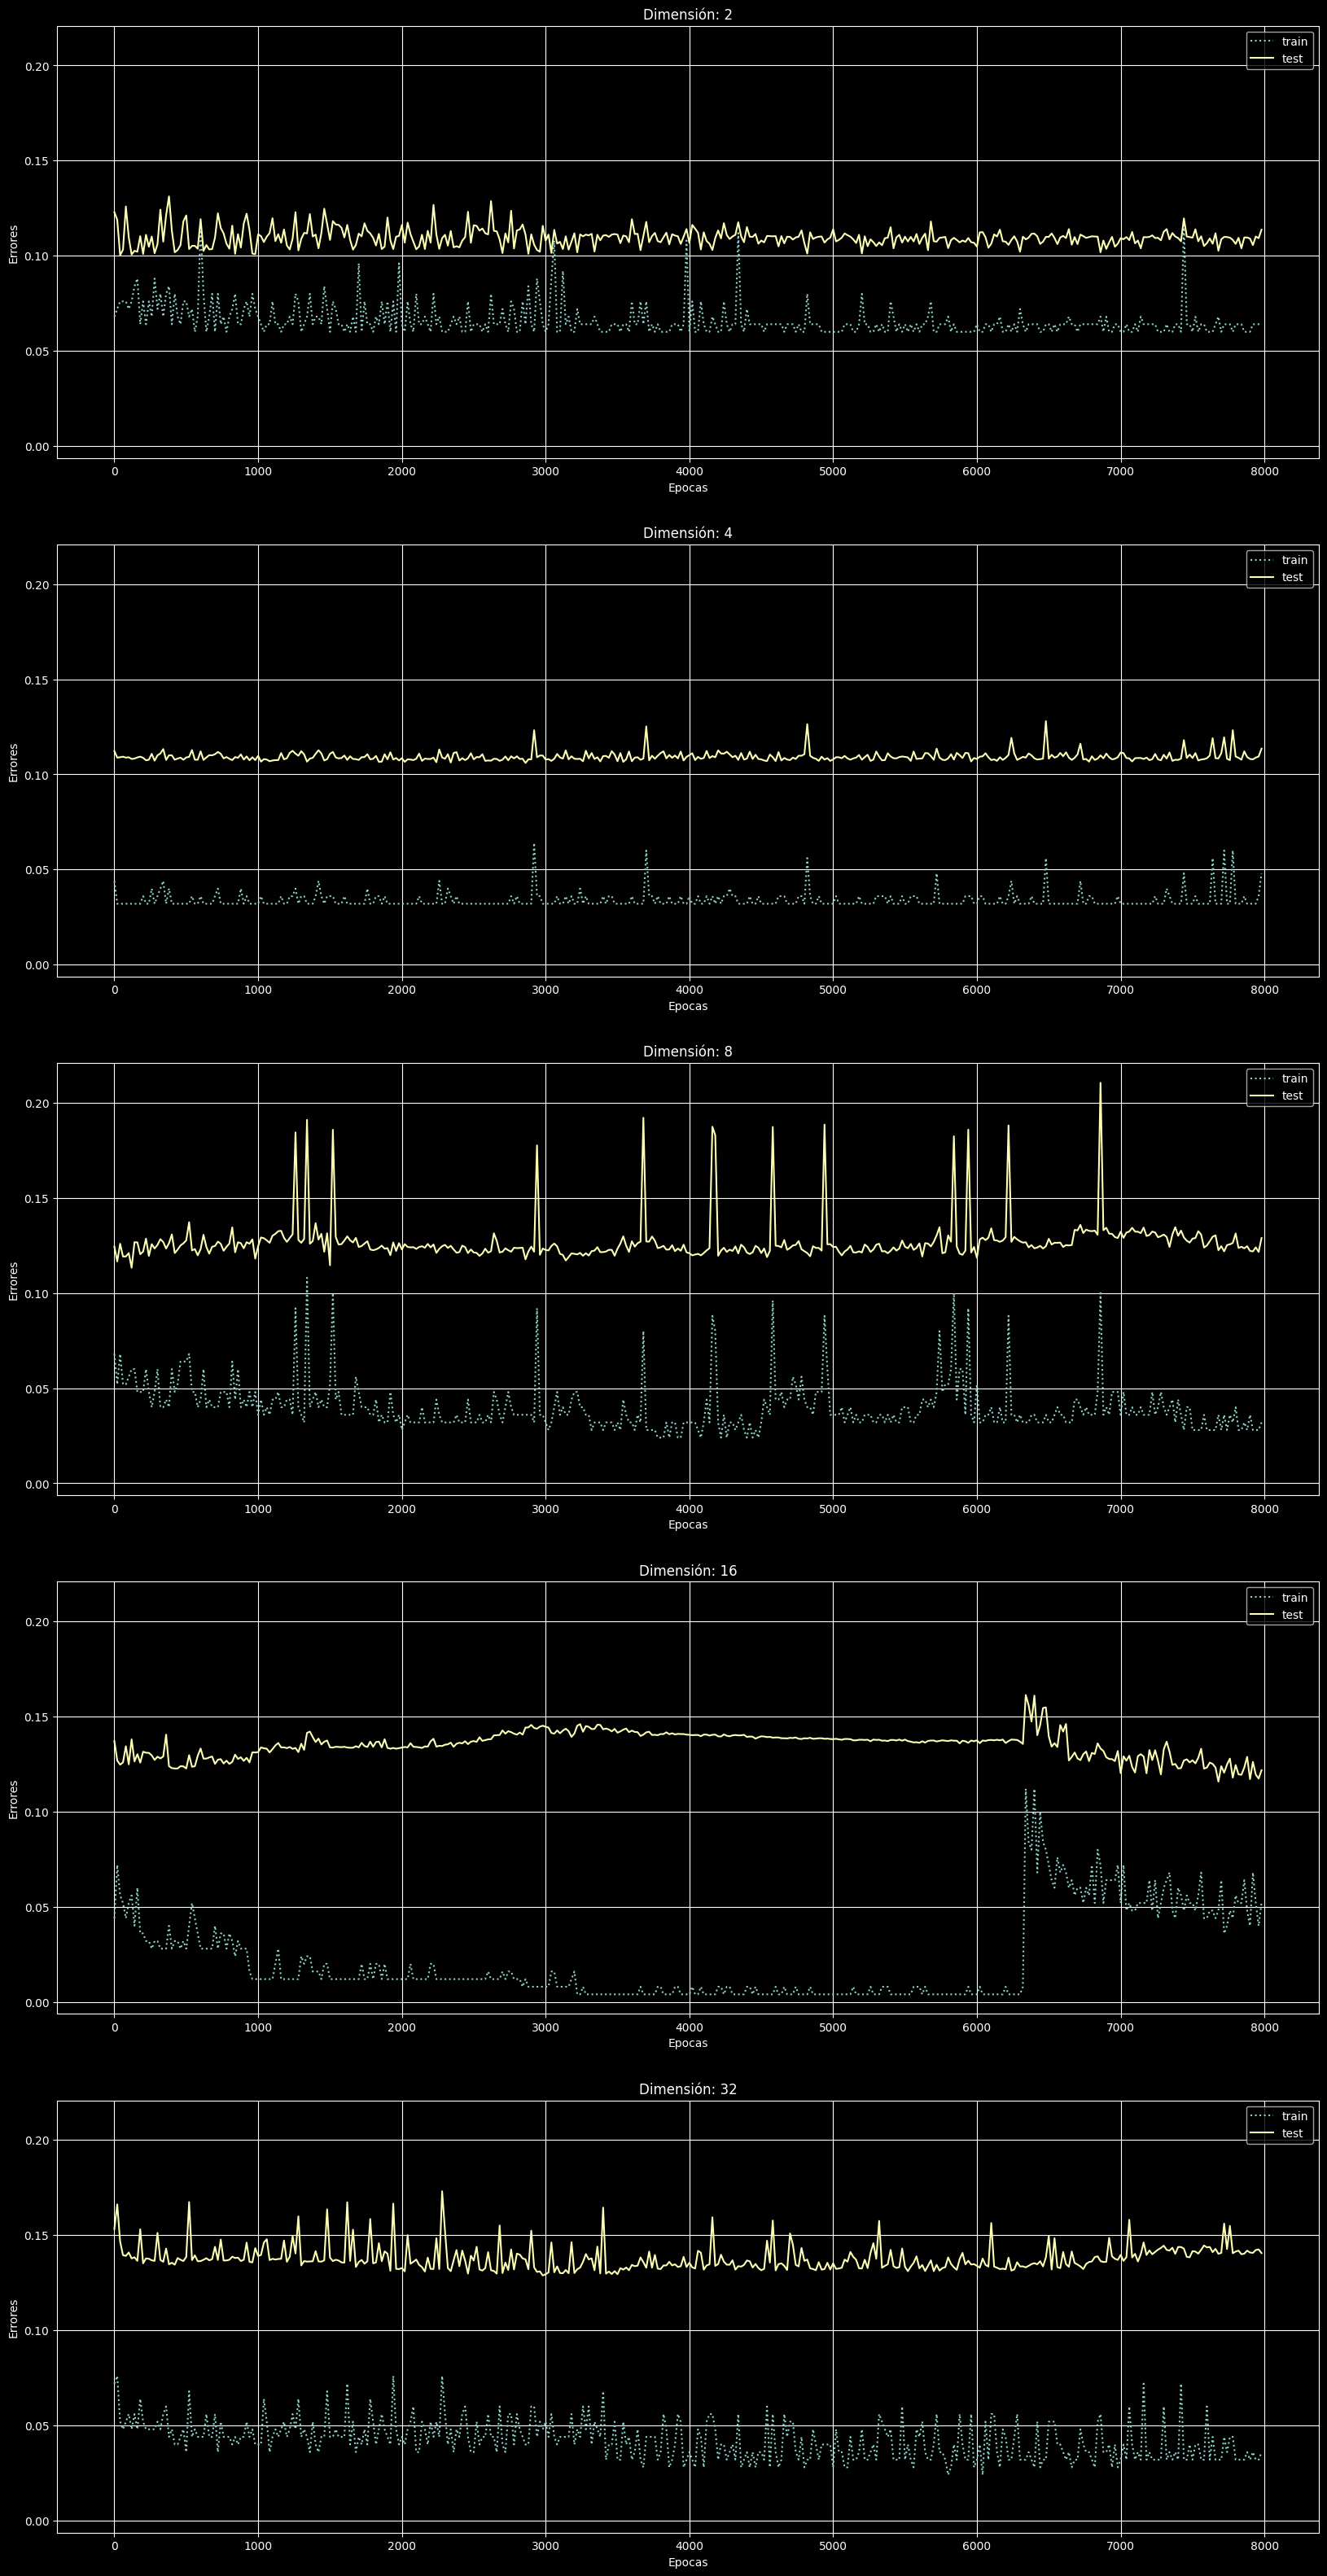

In [ ]:
# GRÁFICA DE LOS ERRORES DIAGONALES
_, _ax = plt.subplots(len(dimensions_ej5), 1, sharey=True, figsize=(20, 40), squeeze=False)

_cont = 0

for _d in range(len(dimensions_ej5)):
    # Lista de los errores totales mínimos de cada época
    _min_errors = []

    # Nos quedamos con la mejor red para el parámetro 'best_gamma'
    for _j in range(len(ej5_diag["nnss"][_d])):
        # Obtengo la lista de errores de test
        _e_train = ej5_diag["nnss"][_d][_j]["e_train"]

        # Obtenemos la norma de los pesos
        _norm_weights = ej5_diag["nnss"][_d][_j]["norm_weight"]

        # Obtenemos el orden de la norma
        _ord = ej5_diag["ord"][_d]

        # Obtenemos el gamma
        _gamma = ej5_diag["gamma"][_d]

        # Calculamos el error total mínimo de entre todas las épocas
        _min_errors.append(min(calc_total_errors(_e_train, _norm_weights, _gamma, _ord)))

    # Obtenemos el índice
    _k = _min_errors.index(min(_min_errors))

    # Nos quedamos con la red asociada a ese valor, y la ploteamos
    _nn = ej5_diag["nnss"][_d][_k]

    plot_errors_wd(_ax[_cont,0], _nn["e_train"], _nn["e_test"], ej5_diag["super_epocas"][_d], ej5_diag["sub_epocas"][_d])

    _ax[_d, 0].set_title(f"Dimensión: {dimensions_ej5[_d]}")

    _cont += 1

plt.show()

## Análisis de las gráficas paralelas vs diagonales

Antes de analizar las gráficas recordemos como afecta la
cantidad de neuronas en la capa intermedia al poder resolutivo de nuestra red.
Un mayor numero de neuronas, permite que la red represente y resuelva
cosas de mayor complejidad (podemos formar funciones más complejas).

Teniendo esto en mente, veamos que sucede al variar las dimensiones.
Al aumentar las dimensiones, el conjunto de datos a clasificar
se vuelve más complejo.

Ahora, si le sumamos la restricción de tener un numero de neuronas (de la capa intermedia) constante
(en un numero no tan elevado) mientras aumentamos las dimensiones de nuestros datos,
por lo explicado anteriormente, nuestra red empieza a perder la capacidad
de generalización y poder resolutivo que tenia en dimensiones más bajas.
En otras palabras, aumentamos la complejidad del problema, pero no así el poder
expresivo y resolutivo de la misma. Esto conlleva a peores resultados.

Al graficar los errores de entrenamiento y testeo, vemos como
al aumentar las dimensione aumenta el overfitting (aumenta el error
de test y disminuye el de entrenamiento). Resultado esperado luego
del análisis hecho anteriormente.

Por otro lado, vemos como las diagonales mantienen un mejor resultado
al aumentar la cantidad de dimensiones (producen menos overfitting).
Parecerían presentar menos inconvenientes a la hora de su clasificación.

## Graficamos los errores en base a la dimensionalidad

In [ ]:
def obtain_err_data_graph(ej5):
    _e_train_graph = []
    _e_test_graph = []

    for _i in range(len(dimensions_ej5)):
        _min_errors = []
        _total_errors_list = []

        for _j in range(len(ej5["nnss"][_i])):
            # Obtengo la lista de errores de train
            _e_train = ej5["nnss"][_i][_j]["e_train"]

            # Obtenemos la norma de los pesos
            _norm_weights = ej5["nnss"][_i][_j]["norm_weight"]

            # Obtenemos el orden de la norma
            _ord = ej5["ord"][_i]

            # Obtenemos el gamma
            _gamma = ej5["gamma"][_i]

            _total_errors = calc_total_errors(_e_train, _norm_weights, _gamma, _ord)
            _total_errors_list.append(_total_errors)

            # Calculamos el error total mínimo de entre todas las épocas
            _min_errors.append(min(_total_errors))

        _min_total_err = min(_min_errors)
        # Obtenemos el índice con la red con menor total error
        _k = _min_errors.index(_min_total_err)

        # Nos quedamos con la red asociada a ese valor
        _nn = ej5["nnss"][_i][_k]

        # Super epoca en la que se logra el _min_total_err dentro
        # de la mejor red
        _e = _total_errors_list[_k].index(_min_total_err)

        _e_test_graph.append(_nn["e_test"][_e])
        _e_train_graph.append(_nn["e_train"][_e])

    return _e_test_graph, _e_train_graph

## Traemos el código de árboles explícitamente

In [ ]:
# Importamos el código general de árboles de decisión
import desicion_tree as dt

In [ ]:
def tree_dimensions_problem():
    C = 0.78
    n_train = 250
    n_test  = 10000
    m = 20

    Ds = [2, 4, 8, 16, 32]

    diag_train = []
    diag_test = []

    paralel_train = []
    paralel_test = []

    for d in Ds:
        res_diag = dt.run_experiment("diagonal", [n_train], d, C, m, n_test)
        res_par = dt.run_experiment("paralelas", [n_train], d, C, m, n_test)

        diag_train.append(res_diag["avg_train_loss"])
        diag_test.append(res_diag["avg_test_loss"])

        paralel_train.append(res_par["avg_train_loss"])
        paralel_test.append(res_par["avg_test_loss"])


    return paralel_test, diag_test, paralel_train, diag_train

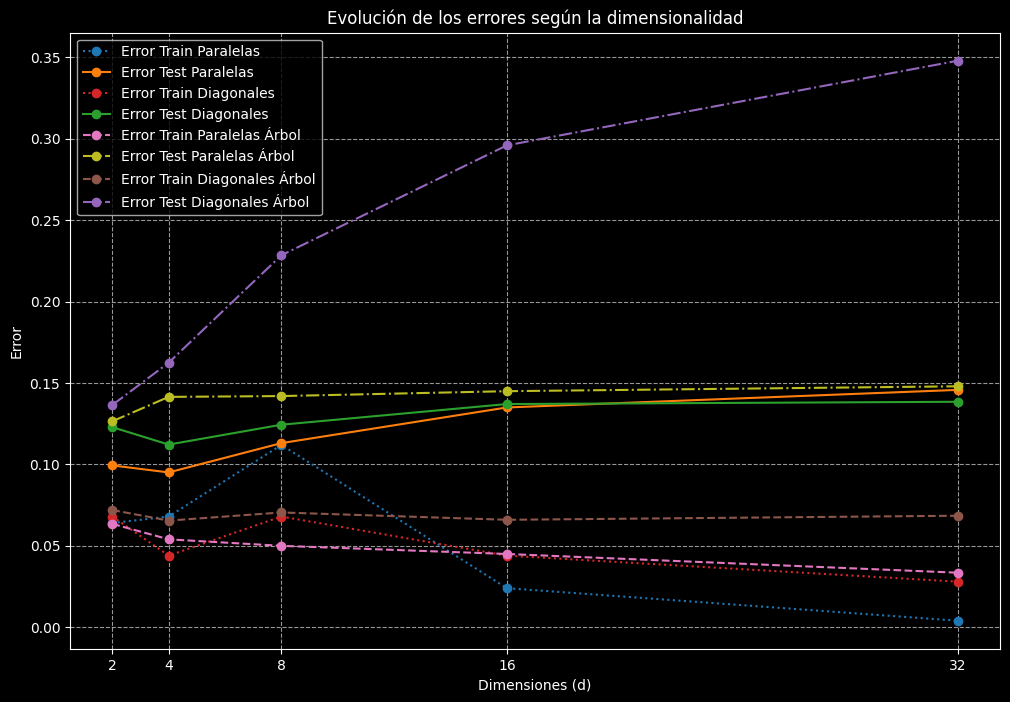

In [ ]:
_e_test_graph_paral, _e_train_graph_paral = obtain_err_data_graph(ej5_paral)
_e_test_graph_diag, _e_train_graph_diag = obtain_err_data_graph(ej5_diag)

_e_test_graph_tree_paral, _e_test_graph_tree_diag, _e_train_graph_tree_paral, _e_train_graph_tree_diag = tree_dimensions_problem()

_, _ax = plt.subplots(1, 1, figsize=(12, 8), squeeze=False)

_ax[0, 0].plot(dimensions_ej5, _e_train_graph_paral, marker='o', linestyle=':', color='tab:blue', label='Error Train Paralelas')
_ax[0, 0].plot(dimensions_ej5, _e_test_graph_paral, marker='o', linestyle='-', color='tab:orange', label='Error Test Paralelas')

_ax[0, 0].plot(dimensions_ej5, _e_train_graph_diag, marker='o', linestyle=':', color='tab:red', label='Error Train Diagonales')
_ax[0, 0].plot(dimensions_ej5, _e_test_graph_diag, marker='o', linestyle='-', color='tab:green', label='Error Test Diagonales')

_ax[0, 0].plot(dimensions_ej5, _e_train_graph_tree_paral, marker='o', linestyle='--', color='tab:pink', label='Error Train Paralelas Árbol')
_ax[0, 0].plot(dimensions_ej5, _e_test_graph_tree_paral, marker='o', linestyle='-.', color='tab:olive', label='Error Test Paralelas Árbol')

_ax[0, 0].plot(dimensions_ej5, _e_train_graph_tree_diag, marker='o', linestyle='--', color='tab:brown', label='Error Train Diagonales Árbol')
_ax[0, 0].plot(dimensions_ej5, _e_test_graph_tree_diag, marker='o', linestyle='-.', color='tab:purple', label='Error Test Diagonales Árbol')

_ax[0, 0].set_xlabel('Dimensiones (d)')
_ax[0, 0].set_ylabel('Error')
_ax[0, 0].set_title('Evolución de los errores según la dimensionalidad')

_ax[0, 0].set_xticks(dimensions_ej5) 

_ax[0, 0].grid(True, linestyle='--', alpha=0.6)
_ax[0, 0].legend()

plt.show()

### Conclusiones Árboles vs Redes Neuronales

Enfoquémonos primero en los resultados de usar paralelas. Con esta generación
de datos podemos ver como las redes neuronales sobre-ajustan los datos de
entrenamiento en mayor medida que los árboles de decisión, llevando el error
de entrenamiento prácticamente a cero.

Por otro lado, en los resultados de usar diagonales podemos ver que los
árboles de decisión tienen un desempeño mucho peor. El error de testeo se
eleva más que el doble con respecto al error de testeo en redes neuronales.
Esto expone que, en este caso, los árboles
tienen un mayor overfitting que las redes neuronales.

En este ejercicio vemos que por lo general, las redes neuronales son más estables frente
al aumento de dimensiones, es decir, son más estables al complejizar los
datos de entrada. A su vez, la generación de datos no tiene tanta
implicancia a la hora de aumentar las dimensiones.

Si bien con redes neuronales vemos un comportamiento de overfitting, no hay
que perder de vista que estamos limitando la cantidad de neuronas en la capa
intermedia. Aun con esta restricción, las redes son más estables que los
árboles frente al aumento de la dimensionalidad. Pareciese ser, que las redes
neuronales tienen una mayor capacidad resolutiva que los árboles de decisión.

# (OPCIONAL) Ejercicio 6. Multiclase.

## A)

## Entrenamos las redes

In [ ]:
def res_ej6(N2, eta, alfa, super_epocas, sub_epocas, val_perc):
    iter = 10

    # Parámetros:
    # eta := learning rate
    # alfa := momentum
    # número de épocas que entrena cada vez
    # número de veces que realizaremos sub-epocas
    # épocas ~= sub_epocas * super_epocas
    # neuronas en la capa oculta

    # Cargamos los datos de test
    X_iris = load_iris().data
    y_iris = load_iris().target

    train_perc = 1 - val_perc

    nns = []

    for i in range(iter):
        # Hacemos el split de testing (1/3 datos de test)
        X, X_test, Y, y_test = skl.model_selection.train_test_split(X_iris, y_iris, test_size=0.33)
        # Generamos los datos de entrenamiento y validación
        X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X, Y, test_size=val_perc)

        # Defino MLP para clasificación
        clasif = MLPClassifier(
            hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=eta,
            momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=sub_epocas
        )

         # Corremos el entrenamiento
        clasif, e_train, e_val, e_test = entrenar_red(clasif, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)

        nns.append( {"nn"    : clasif,
                     "e_train"   : e_train,
                     "e_val"     : e_val,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "neurons" : N2, 
             "learning_rate" : eta,
             "momentum" : alfa,
             "train_perc" : train_perc,
             "val_perc" : val_perc,
             "super_epocas" : super_epocas,
             "sub_epocas" : sub_epocas
           }

In [ ]:
_archivo_cache = "resultados_ej6_a.pkl"

ej6_cases = [(30, 0.01, 0.9, 400, 50, 0.25), 
             (15, 0.001, 0.5, 400, 50, 0.25),
             (30, 0.25, 0.5, 400, 50, 0.25)]

if os.path.exists(_archivo_cache):
    ej6 = joblib.load(_archivo_cache)
else:

    ej6 = {
             "nnss" : [],
             "neurons" : [],
             "learning_rate" : [],
             "momentum" : [],
             "train_perc" : [],
             "val_perc" : [],
             "super_epocas" : [],
             "sub_epocas" : []
           }

    _res_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej6)(_N2, _eta, _alfa, _super_epocas, _sub_epocas, _val_perc) for _N2, _eta, _alfa, _super_epocas, _sub_epocas, _val_perc in ej6_cases
    )

    for _res in _res_paralelos:
        ej6["nnss"].append(_res["nns"])
        ej6["neurons"].append(_res["neurons"])
        ej6["learning_rate"].append(_res["learning_rate"])
        ej6["momentum"].append(_res["momentum"])
        ej6["train_perc"].append(_res["train_perc"])
        ej6["val_perc"].append(_res["val_perc"])
        ej6["super_epocas"].append(_res["super_epocas"])
        ej6["sub_epocas"].append(_res["sub_epocas"])

    joblib.dump(ej6, _archivo_cache)

## Ploteamos la tabla y los errores

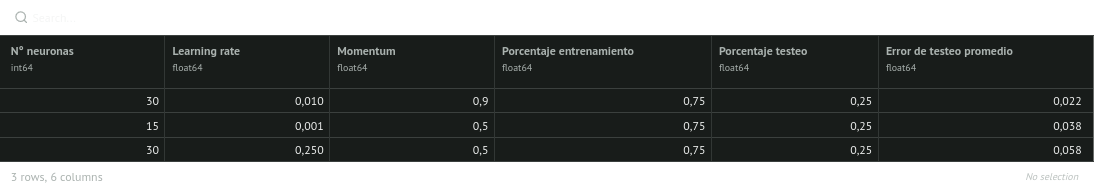

In [ ]:
# Creamos y mostramos la tabla para encontrar la mejor red
_aux_table_ej6 = {
                   "N° neuronas" : [],
                   "Learning rate" : [],
                   "Momentum" : [],
                   "Porcentaje entrenamiento" : [],
                   "Porcentaje testeo" : [],
                   "Error de testeo promedio": [],
                 }

for _i in range(len(ej6["nnss"])):
    _errs_test = []
    for _j in range(len(ej6["nnss"][_i])):
        _min_e_val = min(ej6["nnss"][_i][_j]["e_val"])
        _k = ej6["nnss"][_i][_j]["e_val"].index(_min_e_val)
        _errs_test.append(ej6["nnss"][_i][_j]["e_test"][_k])

    _aux_table_ej6["Error de testeo promedio"].append(round(np.mean(_errs_test),5))
    _aux_table_ej6["N° neuronas"].append(ej6["neurons"][_i])
    _aux_table_ej6["Learning rate"].append(ej6["learning_rate"][_i])
    _aux_table_ej6["Momentum"].append(ej6["momentum"][_i])
    _aux_table_ej6["Porcentaje testeo"].append(ej6["val_perc"][_i])
    _aux_table_ej6["Porcentaje entrenamiento"].append(ej6["train_perc"][_i])

table_ej6 = pd.DataFrame(_aux_table_ej6)
table_ej6

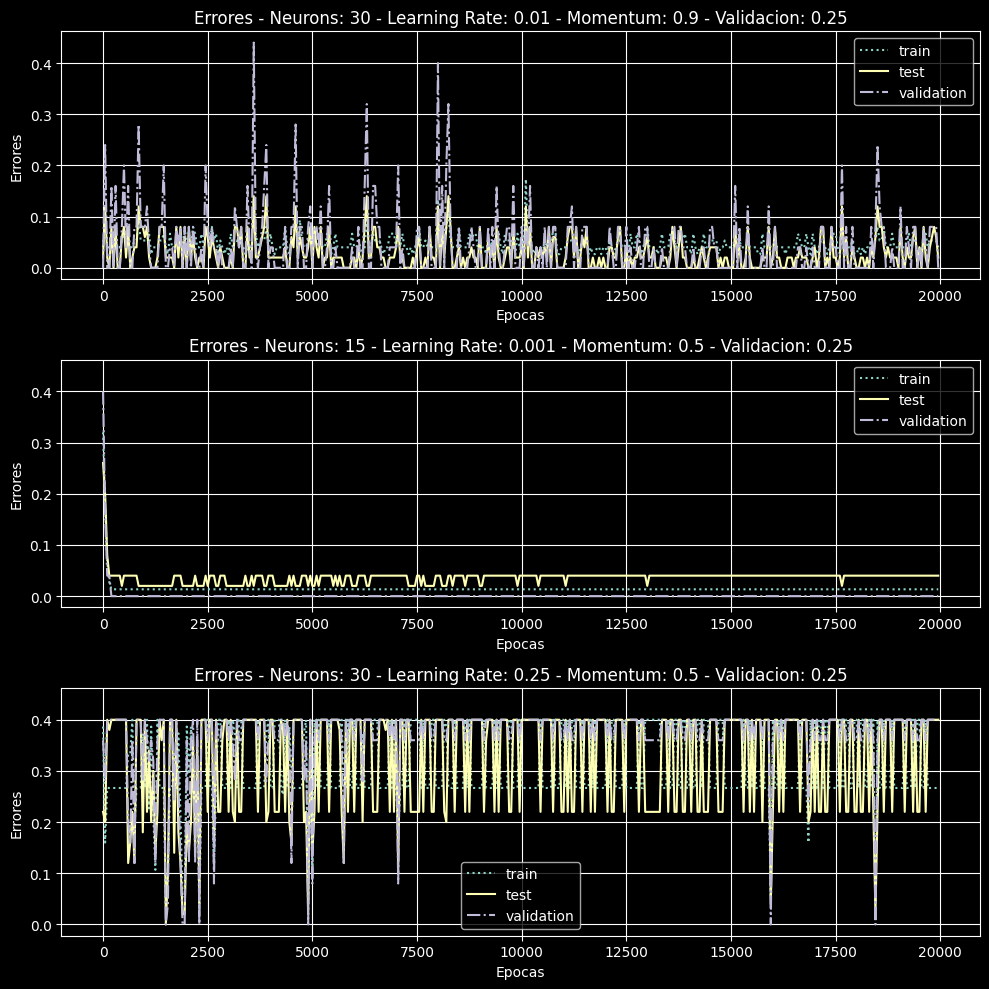

In [ ]:
_fig, _ax = plt.subplots(len(ej6["nnss"]), ncols=1, sharex=False, sharey=True, 
                        figsize=(10, 10), squeeze=False)

for _k in range(len(ej6["nnss"])):
    _find_min_val = []

    for _j in range(len(ej6["nnss"][_k])):
        _find_min_val.append(min(ej6["nnss"][_k][_j]["e_val"]))

    _i = _find_min_val.index(min(_find_min_val))

    _e_train = ej6["nnss"][_k][_i]["e_train"]
    _e_val = ej6["nnss"][_k][_i]["e_val"]
    _e_test = ej6["nnss"][_k][_i]["e_test"]

    plot_errors(_ax[_k, 0], _e_train,
                    _e_test, _e_val,
                    ej6["super_epocas"][_k], ej6["sub_epocas"][_k])

    _ax[_k, 0].set_title(f"Errores - Neurons: {ej6["neurons"][_k]} - Learning Rate: {ej6["learning_rate"][_k]} - Momentum: {ej6["momentum"][_k]} - Validacion: {ej6["val_perc"][_k]}")

plt.tight_layout()

_fig

Luego de ver las gráficas, concluimos que los mejores hiper-parámetros
entre los propuestos son:
- Neuronas: 30
- Learning rate: 0.01
- Momentum: 0.9
- Porcentaje de validación: 0.25
- Super épocas: 400
- Sub épocas: 50

Ya que presentan el mejor error promedió en los datos de test, sin
presentar overfitting.

En este ejercicio, pudimos ver como, con los mismos hiper-parámetros
obtuvimos curvas de aprendizajes muy distintas (aunque los errores promedios se mantenían).
Nosotros creemos que esto se debe principalmente, a que cada red inicializa los pesos de manera random.

## B)

### Entrenamos las redes

In [ ]:
def cargar_datos_ej6(val_per, scaler):
    # Cargamos los datos
    X, y = cargar_csv('./data/faces.data', 960)

    # Spliteamos el training y validacion
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X, y, test_size=val_per)

    # Re-escalamos los datos
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.fit_transform(X_val)

    return X_train_scaled, X_val_scaled, y_train, y_val

In [ ]:
def res_ej6_b():
    iter = 10

    # Parámetros
    eta = 0.001            # eta := learning rate
    alfa = 0.5             # alfa := momentum
    sub_epocas = 20       # número de épocas que entrena cada vez
    eval = 200             # número de veces que realizaremos sub-epocas
    # épocas ~= sub_epocas * super_epocas
    N2 = 15    # neuronas en la capa oculta
    val_perc = 0.25         # porcentaje de validación
    train_perc = round(1 - val_perc,2) # porcentaje de validación

    # Escalador de datos a [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))

    nns = []

    for i in range(iter):
        # Cargamos los datos de entrenamiento y validación
        X_train, X_val, y_train, y_val = cargar_datos_ej6(val_perc, scaler)

        # Cargamos los datos de test
        X, y_test = cargar_csv('./data/faces.test', 960)

        # Re-escalamos los datos
        X_test = scaler.transform(X)


        # Defino MLP para clasificación
        classf = MLPClassifier(
            hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=eta,
            momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=sub_epocas
        )

        classf, e_train, e_val, e_test = entrenar_red(classf, eval, X_train, y_train, X_val, y_val, X_test, y_test)

        # Guardamos el resultado
        nns.append( {"nn"    : classf,
                     "e_train"   : e_train,
                     "e_val"     : e_val,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "neurons" : N2, 
             "learning_rate" : eta,
             "momentum" : alfa,
             "train_perc" : train_perc,
             "val_perc" : val_perc,
             "super_epocas" : eval,
             "sub_epocas" : sub_epocas
           }

In [ ]:
_archivo_cache = "resultados_ej6_b.pkl"

if os.path.exists(_archivo_cache):
    ej6_b = joblib.load(_archivo_cache)
else:

    ej6_b = {
             "nnss" : [],
             "neurons" : [],
             "learning_rate" : [],
             "momentum" : [],
             "train_perc" : [],
             "val_perc" : [],
             "super_epocas" : [],
             "sub_epocas" : []
           }

    _res = res_ej6_b()

    ej6_b["nnss"].append(_res["nns"])
    ej6_b["neurons"].append(_res["neurons"])
    ej6_b["learning_rate"].append(_res["learning_rate"])
    ej6_b["momentum"].append(_res["momentum"])
    ej6_b["train_perc"].append(_res["train_perc"])
    ej6_b["val_perc"].append(_res["val_perc"])
    ej6_b["super_epocas"].append(_res["super_epocas"])
    ej6_b["sub_epocas"].append(_res["sub_epocas"])


    joblib.dump(ej6_b, _archivo_cache)

### Ploteamos la tabla y los errores

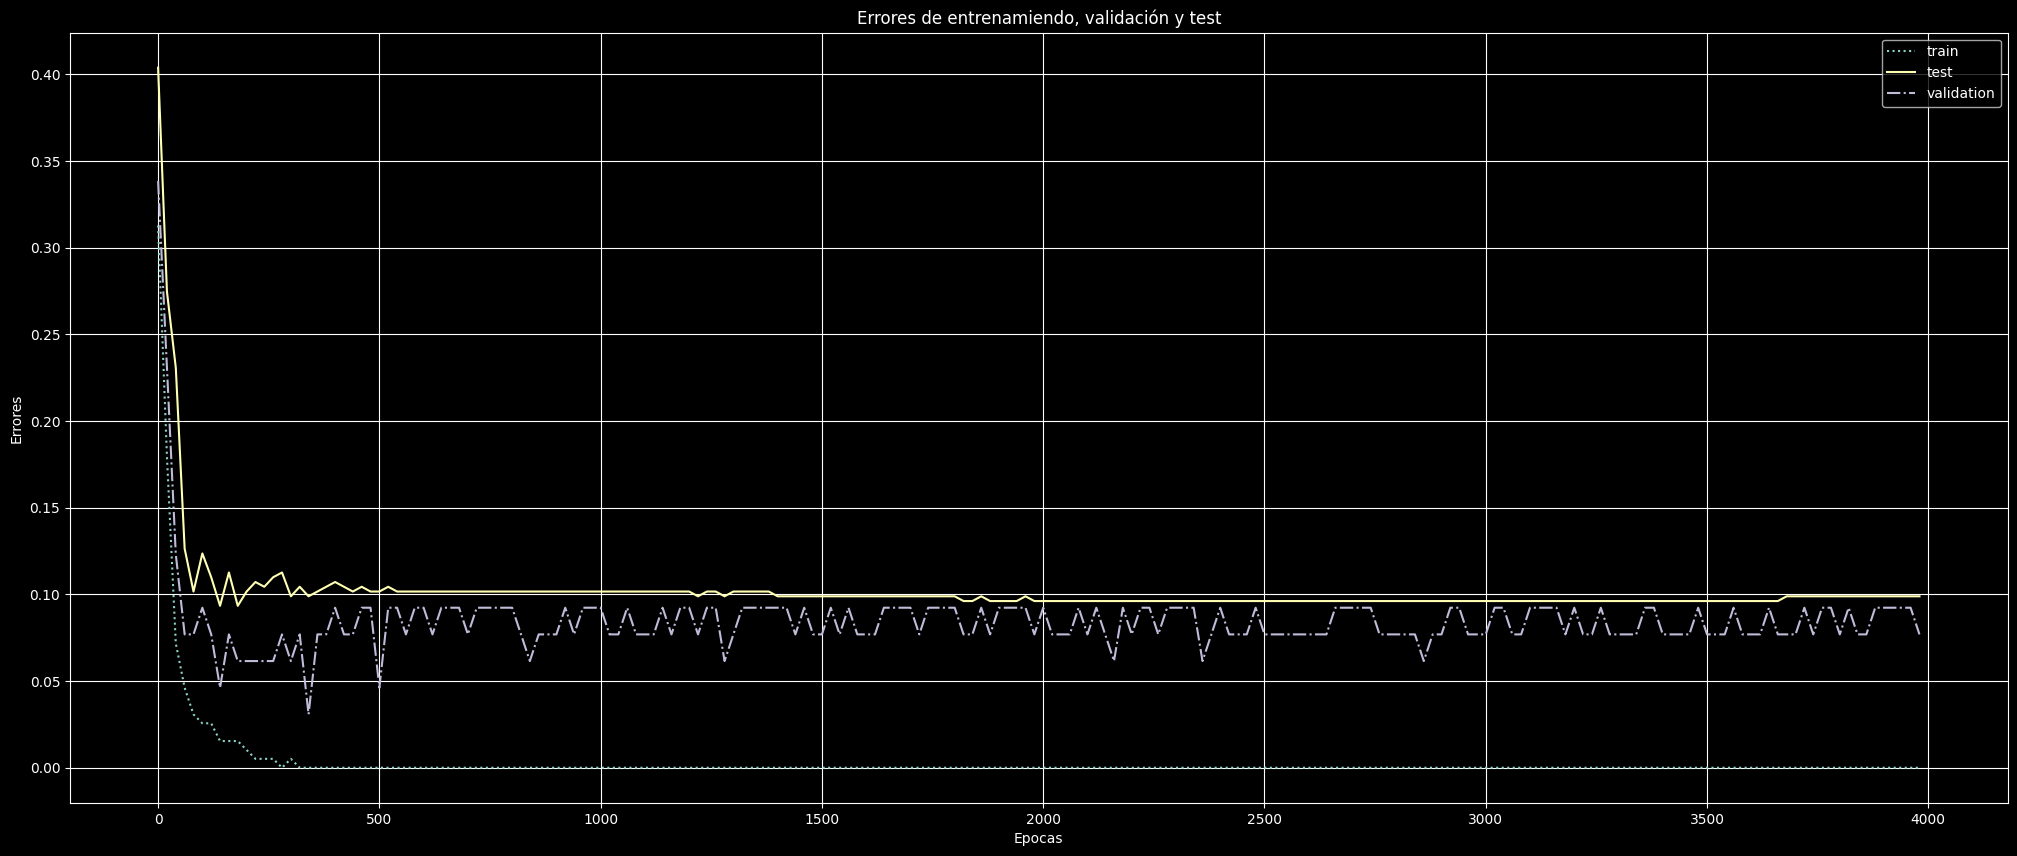

In [ ]:
_k = 0
_find_min_val = []

for _j in range(len(ej6_b["nnss"][_k])):
    _find_min_val.append(min(ej6_b["nnss"][_k][_j]["e_val"]))

_i = _find_min_val.index(min(_find_min_val))

_e_train = ej6_b["nnss"][_k][_i]["e_train"]
_e_val = ej6_b["nnss"][_k][_i]["e_val"]
_e_test = ej6_b["nnss"][_k][_i]["e_test"]


# Ploteamos los errores
_, _ax = plt.subplots(1, 1, sharey=True, figsize=(25, 10), squeeze=False)

plot_errors(_ax[0, 0], _e_train,
                _e_test, _e_val,
                ej6_b["super_epocas"][_k], ej6_b["sub_epocas"][_k])

_ax[0, 0].set_title(f"Errores de entrenamiendo, validación y test")

plt.show()

### Conclusión

A la hora de entrenar la red encontramos varios inconvenientes:

- Al utilizar un learning rate muy alto, se observaba en las curvas de error que el error de testeo era muy alto (comparado con los resultados del análisis del Mitchell). Por ello mismo, fue que lo bajamos de $0.25$ a $0.001$.
- Utilizabamos un valor de super-épocas y sub-épocas muy alto, lo que derivaba en que el entrenamiento tardara mucho tiempo. Debido a esto fue que bajamos de $400$ a $200$ super-épocas y de $50$ a $20$ sub-épocas.

Antes de comparar el resultado obtenido con los resultados del Mitchell, nos parece necesario remarcar que dentro de ese estudio se utilizaron los siguientes hiper-parámetros para entrenar la red:

- 3 neuronas en la capa intermedia. Además, nombra que podría aumentarse su precisión en $1\%$ o $2\%$ si se utilizan 30 neuronas.
- Un learning rate igual a $0.3$.
- Un momentum de $0.3$
- 50 sub-épocas y 1 super-época.

Además especifica que se utiliza el método de `full gradient descent`. A su vez en el Mitchell se explica que los pesos de entrada son son inicializados en cero, y que los pesos de salida inicializados de forma aleatoria (pero en valores pequeños).

Habiendo dicho esto, tenemos que tanto el resultado del Mitchell y nuestro resultado obtuvieron un error del $10\%$ más allá de que variaran los hiper-parámetros.

# (OPCIONAL) Ejercicio 7. Minibatch.

Antes de entrenar las redes, nos parece oportuno explicar que es el tamaño de
batch. El batch size es la cantidad de entradas del conjunto de entrenamiento
que la red neuronal procesa (en forma conjunta) antes de calcular el error y
actualizar los pesos.

**Stochastic gradient decent**

Consiste en poner el tamaño de batch en uno. Cuando hacemos esto, forzamos
a que la red actualice los pesos por cada entrada consumida. Esto provoca
que nos acerquemos y alejemos de la solución en cada actualización, pues
ajustamos los pesos en relación al dato visto. Al hacer esto, tenemos
que la función de error con respecto a las épocas tiene muchos picos, subidas
y bajadas. Es un descenso del error "caótico".

**Batch gradient decent**

El tamaño del batch es el tamaño del dataset. La red espera a ver todos
los datos y luego en base a eso actualizar el error. Se tiene un descenso
del error controlado y directo al mínimo. El problema de hacer esto, es que
al tomar todos los datos para actualizar los pesos (calcular el gradiente)
es muy fácil caer y quedarse estancado en un mínimo local.


**Mini-Batch gradient decent**

Tal como indica el nombre, es un intermedio de las dos opciones anteriores.
Nos permite actualizar los pesos luego de ver una determinada cantidad
de datos del dataset. Al utilizar mini-batch obtenemos funciones de errores
con algunos picos, pero no tanto como la del stochastic. De esta manera,
descendemos al error mínimo de forma controlada pero con menos
probabilidad de quedar estancado en un mínimo local
(calculamos multiples gradientes antes de actualizar).

## Entrenamos las redes

In [ ]:
def cargar_datos_ej7(val_per):
    # Cargamos los datos
    X, y = cargar_csv('./data/ssp.data', 12)

    # Spliteamos el training y validacion
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(X, y, test_size=val_per)
    return X_train, X_val, y_train, y_val

In [ ]:
def res_ej7(batch_size):
    iter = 10

    # Parámetros
    eta = 0.05             # eta := learning rate
    alfa = 0.3             # alfa := momentum
    sub_epocas = 200       # número de épocas que entrena cada vez
    eval = 2000            # número de veces que realizaremos sub-epocas
    # épocas ~= sub_epocas * super_epocas
    N2 = 30     # neuronas en la capa oculta
    val_perc = 0.2         # porcentaje de validación
    train_perc = round(1 - val_perc,2) # porcentaje de validación

    # Cargamos los datos de test
    X_test, y_test = cargar_csv('./data/ssp.test', 12)


    nns = []

    for i in range(iter):
        # Cargamos los datos de entrenamiento y validación
        X_train, X_val, y_train, y_val = cargar_datos_ej7(val_perc)


        # Defino MLP para regresión
        regr = MLPRegressor(
            hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=batch_size, learning_rate='constant', learning_rate_init=eta,
            momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=sub_epocas
        )

        # Corremos el entrenamiento
        regr, e_train, e_val, e_test = entrenar_red_rgr(regr, eval, X_train, y_train, X_val, y_val, X_test, y_test)

        # Guardamos el resultado
        nns.append( {"regr"    : regr,
                     "e_train"   : e_train,
                     "e_val"     : e_val,
                     "e_test"    : e_test})

    return { 
             "nns" : nns,
             "batch_size": batch_size,
             "super_epocas" : eval,
             "sub_epocas" : sub_epocas
           }

Entrenamos la red con distintos tamaños de batchs.

In [ ]:
_archivo_cache = "resultados_ej7.pkl"

# Notemos que un batch_size x, hace que halla: size_training_dataset/batch_size actualizaciones del gradiente. Por lo tanto:
#
# batch_size = 20 --> (180*0.8)/20 = 7.2 actualizaciones del gradiente
# batch_size = 30 --> (180*0.8)/30 = 4.8 actualizaciones del gradiente
ej7_cases = [1,20,30]

if os.path.exists(_archivo_cache):
    ej7 = joblib.load(_archivo_cache)
else:
    ej7 = { 
            "nnss": [],
            "batch_size": [],
            "super_epocas": [],
            "sub_epocas": []
          }

    # 1. Ejecutamos todos los casos en paralelo
    _resultados_paralelos = Parallel(n_jobs=-1)(
        delayed(res_ej7)(_c) for _c in ej7_cases
    )

    for _res in _resultados_paralelos:
        ej7["nnss"].append(_res["nns"])
        ej7["batch_size"].append(_res["batch_size"])
        ej7["super_epocas"].append(_res["super_epocas"])
        ej7["sub_epocas"].append(_res["sub_epocas"])

    joblib.dump(ej7, _archivo_cache)

## Plotamos un gráfico para cada caso

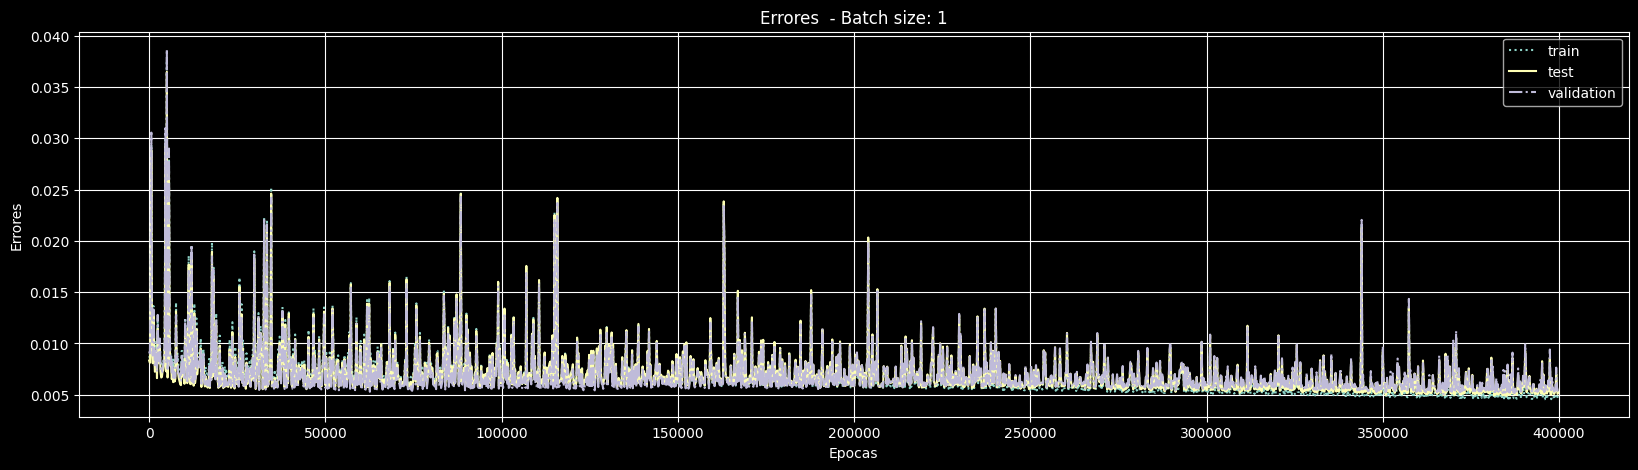

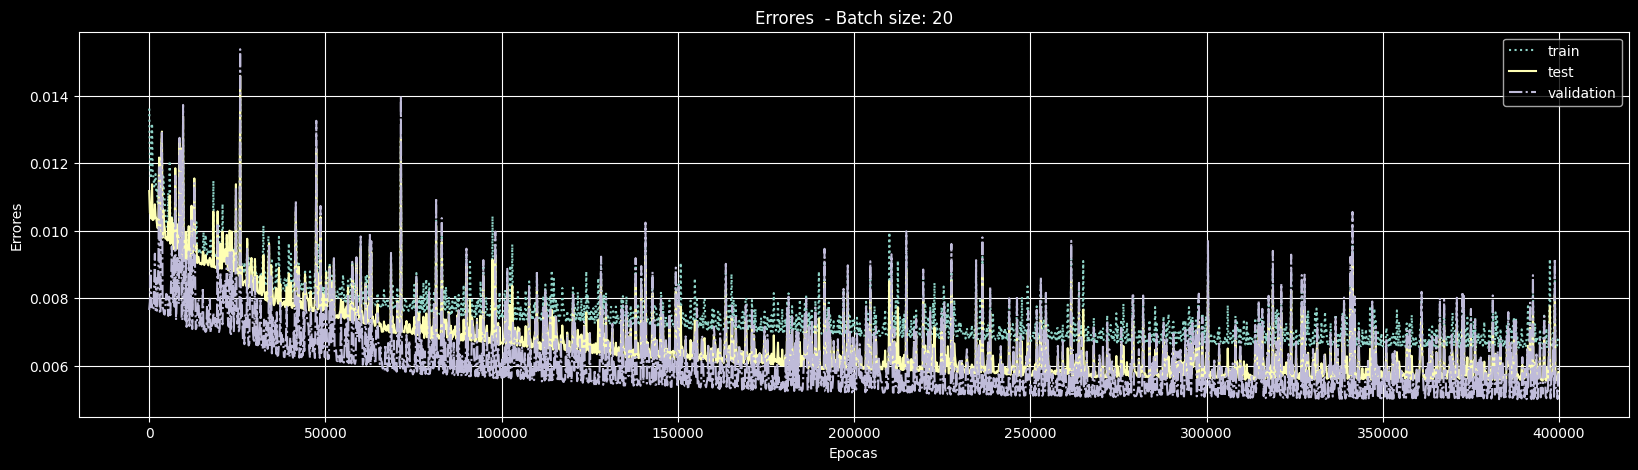

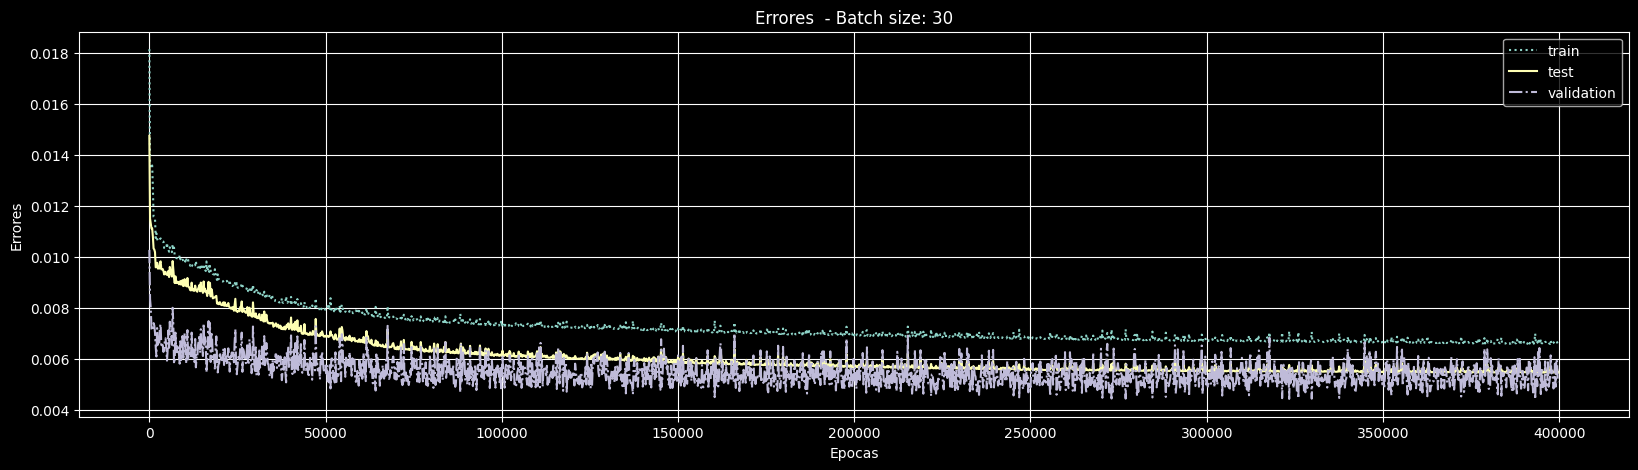

In [ ]:
for _k in range(len(ej7["nnss"])):
    _find_min_val = []

    for _j in range(len(ej7["nnss"][_k])):
        _find_min_val.append(min(ej7["nnss"][_k][_j]["e_val"]))

    _i = _find_min_val.index(min(_find_min_val))

    _e_train = ej7["nnss"][_k][_i]["e_train"]
    _e_val = ej7["nnss"][_k][_i]["e_val"]
    _e_test = ej7["nnss"][_k][_i]["e_test"]

    # Ploteamos los errores
    _, _ax = plt.subplots(1, 1, sharey=True, figsize=(20, 5), squeeze=False)

    plot_errors(_ax[0, 0], _e_train,
                    _e_test, _e_val,
                    ej7["super_epocas"][_k], ej7["sub_epocas"][_k])

    _ax[0, 0].set_title(f"Errores  - Batch size: {round(ej7["batch_size"][_k])}")
    plt.show()

Podemos observar que a medida que aumentamos el tamaño del batch, las curvas
de error son más suaves (los picos son más chicos). Lo que se corresponde
con el comportamiento esperado.

Por otro lado, cuando disminuimos el tamaño de batch la distancia entre
los errores de entrenamiento y test disminuye considerablemente a comparación
con un tamaño de batch grande. Esto puede deberse, a que las redes con menor
tamaño de batch realizan más actualizaciones del gradiente que aquellas
con tamaño de batch más grande, por lo que corrigen más veces los pesos.
Por esto mismo, opinamos que si las últimas dos redes se entrenasen con
más épocas, se observaría la misma convergencia que en la primer gráfica.